In [1]:
#Installation + Restart automatique pour que Python détecte le package installé

import os, sys

try:
    import dllm
    print("dllm déjà installé.")

except ImportError:
    print("Installation de dllm depuis GitHub.")
    os.system("git clone https://github.com/ZHZisZZ/dllm.git 2>/dev/null || true") #2>/dev/null || true permet d'ignorer l'erreur si le git clone existe déjà
    os.system("pip install -e dllm/ -q")
    os.system("pip install torch transformers accelerate datasets -q")
    os.system("pip install evaluate rouge_score bert_score sacrebleu -q")

    print("Installation terminée !")
    print("Restart automatique du kernel.") #Important pour que Python prenne en compte les installations

    import time
    time.sleep(3)

    # Relance de python
    os.kill(os.getpid(), 9)

dllm déjà installé.


In [2]:
# Imports & chargement MDLM
import torch
import numpy as np
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForMaskedLM

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

MODEL_NAME = "dllm-hub/Qwen3-0.6B-diffusion-mdlm-v0.1"

#Tokenizer : on passe de phrase à des tokens
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

#Chargement du modèle
model = AutoModelForMaskedLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    trust_remote_code=True
).to(device).eval()

# Pad pour égaliser la longueur des phrases avec [PAD] ou le token de fin de phrase eos_token
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
pad_id = tokenizer.pad_token_id
mask_id = tokenizer.mask_token_id #Pour masquer des mots que l'IA doit deviner

print(f"Modèle chargé | mask_token_id={mask_id} | pad_token_id={pad_id}")

Device : cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Modèle chargé | mask_token_id=151669 | pad_token_id=151643


In [3]:
# Fonctions MDLM (à ne PAS modifier) -> pris de Hugging Face

def add_gumbel_noise(logits, temperature):
    """
    Ajoute du bruit mathématique (Gumbel) aux prédictions du modèle.
    But : Éviter que le modèle génère des phrases trop plates ou répétitives.
    Plus la 'temperature' est haute, plus on force le modèle à être créatif
    (en choisissant parfois des mots moins probables).
    """
    if temperature == 0:
        return logits
    logits = logits.to(torch.float64) # Haute précision pour les calculs de probabilités
    noise = torch.rand_like(logits, dtype=torch.float64)
    gumbel_noise = (-torch.log(noise)) ** temperature
    return logits.exp() / gumbel_noise


def get_num_transfer_tokens(mask_index, steps):
    """
    Agit comme un "planificateur".
    But : Calculer combien de jetons [MASK] on a le droit de transformer en vrais mots à chaque étape.
    Exemple : S'il y a 64 masques et 8 étapes, la fonction dira au modèle
    de figer exactement 8 mots par étape (le 'base') pour avancer progressivement.
    """
    mask_num = mask_index.sum(dim=1, keepdim=True)
    base = mask_num // steps
    remainder = mask_num % steps
    num_transfer_tokens = (
        torch.zeros(mask_num.size(0), steps, device=mask_index.device, dtype=torch.int64) + base
    )
    for i in range(mask_num.size(0)):
        num_transfer_tokens[i, :remainder[i]] += 1
    return num_transfer_tokens


@torch.no_grad() # Désactive l'apprentissage (rétropropagation) pour économiser la mémoire RAM
def generate_mdlm(model, prompt, prompt_lens, pad_id,
                  steps=64, max_new_tokens=128, block_size=64,
                  temperature=0.0, cfg_scale=0.0, remasking="low_confidence"):
    """
    Le moteur principal de génération MDLM.
    Il part d'un texte rempli de masques et les révèle petit à petit.
    """
    batch_size = prompt.size(0)
    total_length = int(prompt_lens.max().item()) + max_new_tokens

    # 1. INITIALISATION DU TENSEUR GÉANT
    # On crée une grille vide remplie de pad_id
    x = torch.full((batch_size, total_length), pad_id, dtype=torch.long, device=device)

    # On y injecte la question (prompt) et on remplit la zone de réponse avec des [MASK]
    for i, length in enumerate(prompt_lens.tolist()):
        x[i, :length] = prompt[i, :length]              # Zone fixe (La question)
        x[i, length:length + max_new_tokens] = mask_id  # Zone à générer (Que des masques !)

    # 2. VERROUILLAGE DE LA QUESTION
    # On crée un masque booléen (True/False) pour ne jamais modifier les mots de la question
    prompt_index = (
        torch.arange(total_length, device=device).unsqueeze(0)
        < prompt_lens.unsqueeze(1)
    )
    positions = torch.arange(total_length, device=device)

    # 3. DÉBRUITAGE PAR BLOCS (Le cœur de la diffusion)
    # Pour ne pas saturer la mémoire, on démasque par blocs (ex: 64 tokens par 64 tokens)
    assert max_new_tokens % block_size == 0, \
        f"max_new_tokens ({max_new_tokens}) doit être divisible par block_size ({block_size})"
    num_blocks = max_new_tokens // block_size
    assert steps % num_blocks == 0
    steps_per_block = steps // num_blocks

    for num_block in range(num_blocks):
        block_start = prompt_lens + num_block * block_size
        block_end = block_start + block_size

        init_block_mask = (
            (positions.unsqueeze(0) >= block_start.unsqueeze(1))
            & (positions.unsqueeze(0) < block_end.unsqueeze(1))
            & (x == mask_id)
        )

        # On demande au planificateur combien de mots révéler à ce tour-ci
        num_transfer_tokens = get_num_transfer_tokens(init_block_mask, steps_per_block)

        # LA BOUCLE DE DIFFUSION (Génère -> Évalue la confiance -> Remasque)
        for i in range(steps_per_block):
            block_mask = (
                (positions.unsqueeze(0) >= block_start.unsqueeze(1))
                & (positions.unsqueeze(0) < block_end.unsqueeze(1))
                & (x == mask_id)
            )

            # A. Prédiction
            if cfg_scale > 0.0:
                un_x = x.clone()
                un_x[prompt_index] = mask_id
                x_ = torch.cat([x, un_x], dim=0)
                logits = model(x_).logits
                logits, un_logits = torch.chunk(logits, 2, dim=0)
                logits = un_logits + (cfg_scale + 1.0) * (logits - un_logits)
            else:
                logits = model(x).logits # Le modèle devine ce qui se cache sous les masques

            # B. Ajout de créativité et choix du mot
            logits_with_noise = add_gumbel_noise(logits, temperature=temperature)
            x0 = torch.argmax(logits_with_noise, dim=-1) # x0 contient les mots choisis

            # C. Calcul de la confiance (Le "remasking")
            if remasking == "low_confidence":
                # Le modèle calcule son pourcentage de certitude (ex: 95% sûr que c'est ce mot)
                p = F.softmax(logits, dim=-1)
                x0_p = torch.gather(p, dim=-1, index=x0.unsqueeze(-1)).squeeze(-1)
            elif remasking == "random":
                x0_p = torch.rand_like(x0, dtype=torch.float)
            else:
                raise NotImplementedError(remasking)

            # D. Validation et Remasquage
            confidence = torch.full_like(x0_p, -np.inf)
            confidence = torch.where(block_mask, x0_p, confidence)
            x0 = torch.where(block_mask, x0, x)

            # On cherche les "k" mots avec la plus haute confiance pour ce tour
            transfer_index = torch.zeros_like(x0, dtype=torch.bool)
            for j in range(confidence.shape[0]):
                k = int(num_transfer_tokens[j, i].item())
                if k == 0:
                    continue
                # On valide définitivement les k meilleurs mots
                _, select_index = torch.topk(confidence[j], k=k)
                transfer_index[j, select_index] = True

            # Les mots validés remplacent les [MASK] dans notre grille principale (x)
            # Les autres mots redeviennent des [MASK] pour la boucle suivante
            x[transfer_index] = x0[transfer_index]

    return x

In [4]:
# Logique de génération (Zero-shot & Few-shot)
import random
import torch
import re

def build_conversation(table_text, few_shot_examples=None):
    """Construit le template de conversation Qwen3 pour MDLM."""
    conversation = [
        {
            "role"   : "system",
            "content": "You are a data-to-text assistant. Given a table, write a concise and factually accurate one-sentence description."
        }
    ]

    # Injection des exemples few-shot
    if few_shot_examples:
        for ex in few_shot_examples:
            conversation.append({
                "role"   : "user",
                "content": f"Table:\n{ex['serialized_table']}\n\nDescription:"
            })
            conversation.append({
                "role"   : "assistant",
                "content": ex["reference"]
            })

    # Question principale
    conversation.append({
        "role"   : "user",
        "content": f"Table:\n{table_text}\n\nDescription:"
    })
    return conversation


def generate_descriptions_mdlm(examples, train_data=None, few_shot_k=0,
                                n_samples=3, max_new_tokens=128,
                                steps=32, block_size=64, temperature=0.5,
                                max_prompt_len=768):
    """Génère les descriptions en itérant sur les exemples."""
    if few_shot_k > 0 and train_data is None:
        raise ValueError("train_data est requis pour le few-shot")

    print(f"Mode : {'Few-shot (k=' + str(few_shot_k) + ')' if few_shot_k > 0 else 'Zero-shot'} | {len(examples)} exemples")
    all_predictions = []

    for idx, example in enumerate(examples):
        table_text = example["serialized_table"]

        # Sélection des exemples (on exclut l'exemple actuel)
        few_shot_examples = None
        if few_shot_k > 0:
            pool = [ex for ex in train_data if ex.get("serialized_table") != table_text]
            few_shot_examples = random.sample(pool, k=min(few_shot_k, len(pool)))

        # Construction et tokenisation
        conversation = build_conversation(table_text, few_shot_examples)
        prompt_str = tokenizer.apply_chat_template(conversation, add_generation_prompt=True, tokenize=False)

        inputs = tokenizer(prompt_str, add_special_tokens=False, return_tensors="pt")
        prompt_ids = inputs["input_ids"].view(-1).tolist()[:max_prompt_len]

        encoded = [prompt_ids]
        prompt_lens = torch.tensor([len(e) for e in encoded], dtype=torch.long, device=device)
        max_p = max(prompt_lens).item()
        prompt_tensor = torch.full((len(encoded), max_p), pad_id, dtype=torch.long, device=device)

        for i, ids in enumerate(encoded):
            prompt_tensor[i, :len(ids)] = torch.tensor(ids, dtype=torch.long, device=device)

        # Génération
        sample_descriptions = []
        for sample_idx in range(n_samples):
            current_temp = 0.0 if sample_idx == 0 else temperature
            out = generate_mdlm(
                model, prompt_tensor, prompt_lens, pad_id,
                steps=steps, max_new_tokens=max_new_tokens,
                block_size=block_size, temperature=current_temp,
                remasking="low_confidence"
            )
            start = int(prompt_lens[0].item())
            new_tokens = out[0, start:start + max_new_tokens].tolist()
            text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
            # CORRECTION DU BRUIT
            # Retire tout ce qui se trouve entre <think> et </think>, ainsi que les balises
            import re
            text = re.sub(r'<think>.*?</think>\s*', '', text, flags=re.DOTALL)
            text = text.strip() # Enlève les espaces en trop
            sample_descriptions.append(text)

        all_predictions.append(sample_descriptions)
        if (idx + 1) % 10 == 0:
            print(f"  [{idx+1}/{len(examples)}] '{sample_descriptions[0][:75]}...'")

    return all_predictions

In [5]:
# Chargement des données
import json
from google.colab import drive
drive.mount('/content/drive')

FOLDER_PATH = "/content/drive/MyDrive/genai/data/"

with open(f"{FOLDER_PATH}eval_subset.json", "r") as f:
    eval_subset = json.load(f)

with open(f"{FOLDER_PATH}train_subset.json", "r") as f:
    train_subset = json.load(f)

# SOUS-ENSEMBLE DE TEST : On force à 50 pour que ça tourne vite
N_EVAL = 50
subset_eval = eval_subset[:N_EVAL]

print(f"train_subset (pour piocher le Few-Shot) : {len(train_subset)} exemples")
print(f"subset_eval (ce qu'on évalue) : {len(subset_eval)} exemples")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
train_subset (pour piocher le Few-Shot) : 5000 exemples
subset_eval (ce qu'on évalue) : 50 exemples


In [10]:
# --- CELLULE 6 : Fonctions d'évaluation (Alignées sur GPT-2) ---
import torch
import torch.nn.functional as F
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer
import numpy as np
from transformers import AutoTokenizer, AutoModel
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("Chargement des modèles d'évaluation.")
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased").to(device).eval()

def get_embeddings_batch(texts):
    inputs = bert_tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state

def bertscore_batch(preds, refs):
    emb_pred = get_embeddings_batch(preds)
    emb_ref = get_embeddings_batch(refs)
    scores = []
    for i in range(len(preds)):
        p, r = F.normalize(emb_pred[i], dim=1), F.normalize(emb_ref[i], dim=1)
        sim = torch.mm(p, r.T)
        precision, recall = sim.max(dim=1).values.mean(), sim.max(dim=0).values.mean()
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        scores.append(f1.item())
    return sum(scores) / len(scores) if scores else 0.0

def calculate_bleu_rouge_batch(preds, refs):
    bleu_scores, rouge1_f1_scores, rouge2_f1_scores, rougel_f1_scores = [], [], [], []
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    bleu_weights = (0.25, 0.25, 0.25, 0.25)

    for pred, ref in zip(preds, refs):
        tokenized_ref, tokenized_pred = [word_tokenize(ref)], word_tokenize(pred)
        try:
            bleu_scores.append(sentence_bleu(tokenized_ref, tokenized_pred, weights=bleu_weights))
        except ZeroDivisionError:
            bleu_scores.append(0.0)

        scores = scorer.score(ref, pred)
        rouge1_f1_scores.append(scores['rouge1'].fmeasure)
        rouge2_f1_scores.append(scores['rouge2'].fmeasure)
        rougel_f1_scores.append(scores['rougeL'].fmeasure)

    return (sum(bleu_scores)/len(bleu_scores) if bleu_scores else 0,
            sum(rouge1_f1_scores)/len(rouge1_f1_scores) if rouge1_f1_scores else 0,
            sum(rouge2_f1_scores)/len(rouge2_f1_scores) if rouge2_f1_scores else 0,
            sum(rougel_f1_scores)/len(rougel_f1_scores) if rougel_f1_scores else 0)

def compute_metrics(predictions_list, references_list):
    flat_preds = [preds[0] for preds in predictions_list]
    single_refs = [refs[0] if isinstance(refs, list) else refs for refs in references_list]

    avg_bleu, avg_rouge1, avg_rouge2, avg_rougel = calculate_bleu_rouge_batch(flat_preds, single_refs)
    avg_bertscore = bertscore_batch(flat_preds, single_refs)

    metrics = {
        "BLEU": round(avg_bleu, 4), "ROUGE-1": round(avg_rouge1, 4),
        "ROUGE-2": round(avg_rouge2, 4), "ROUGE-L": round(avg_rougel, 4),
        "BERTScore": round(avg_bertscore, 4),
    }
    for k, v in metrics.items(): print(f"   {k:12s} : {v:.4f}")
    return metrics

def compute_self_bleu(predictions_list):
    self_bleu_scores = []
    bleu_weights = (0.25, 0.25, 0.25, 0.25)
    for preds in predictions_list:
        if len(preds) < 2: continue
        scores = []
        for i, hyp in enumerate(preds):
            refs = [p for j, p in enumerate(preds) if j != i]
            try:
                scores.append(sentence_bleu([word_tokenize(r) for r in refs], word_tokenize(hyp), weights=bleu_weights))
            except ZeroDivisionError:
                scores.append(0.0)
        self_bleu_scores.append(np.mean(scores))
    mean_self_bleu = np.mean(self_bleu_scores)
    print(f"   Self-BLEU    : {mean_self_bleu:.4f}")
    return mean_self_bleu

Chargement des modèles d'évaluation.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


DÉMARRAGE DU ZERO-SHOT
Mode : Zero-shot | 50 exemples
  [10/50] 'The table provided a summary of the player's game-game player,, RPG,, avera...'
  [20/50] 'The table indicates, the event in the Olympic Games, held in Los Angeles, U...'
  [30/50] 'The table presents the the results of the the 2018–19 JGP Final, which the ...'
  [40/50] 'The 196 Peace Marathon, also known the Košice Peace Marathon, was held in K...'
  [50/50] 'The table ", " Meadows" represents a club club, specifically a water sports...'

DÉMARRAGE DU FEW-SHOT (3 exemples)
Mode : Few-shot (k=3) | 50 exemples
  [10/50] 'The table provides the Gameplay, Name, Age, GP,, RPG,, AP,, and PG, for the...'
  [20/50] 'The 1500 meters event at the  Games in Los Angeles, United States, specific...'
  [30/50] 'The 2018–19 JGP Junior Junior, the title the Junior Junior Junior Junior Ju...'
  [40/50] 'The 1st Peace Marathon in 1976, held in Koše, Czechoslovakia, was the by th...'
  [50/50] 'M 1910, 1,2,2,3,2,3, and, later, later, lat

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

   BLEU         : 0.0196
   ROUGE-1      : 0.2552
   ROUGE-2      : 0.0962
   ROUGE-L      : 0.1955
   BERTScore    : 0.5969
   Self-BLEU    : 0.1936

>>> Résultats Few-Shot :
   BLEU         : 0.0275
   ROUGE-1      : 0.2085
   ROUGE-2      : 0.0755
   ROUGE-L      : 0.1684
   BERTScore    : 0.5699
   Self-BLEU    : 0.1603


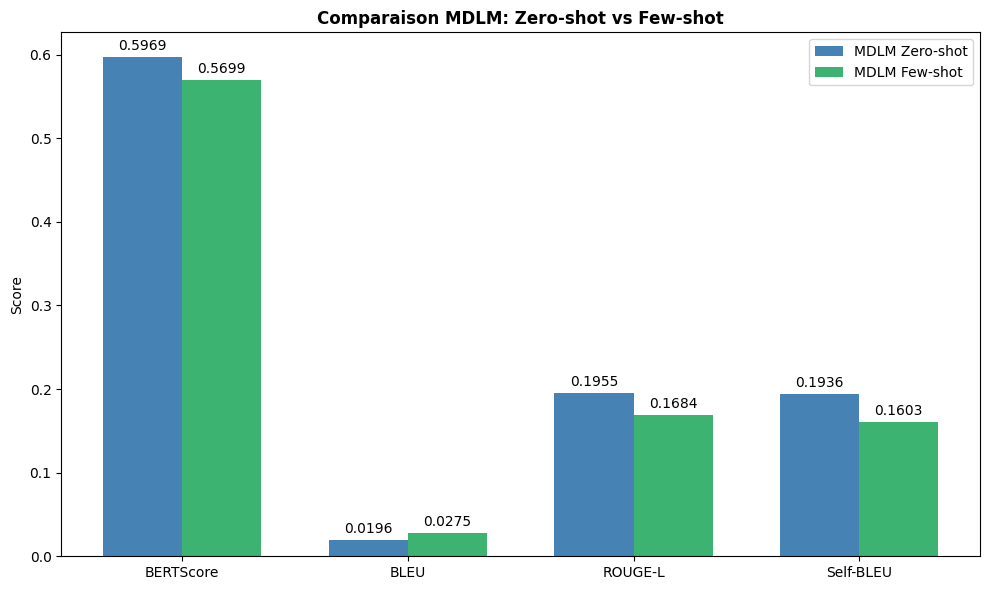

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/genai/data//comparaison_results/mdlm_final_results.json'

In [ ]:
# Exécution Principale (Zero vs Few-Shot) et Graphique
import matplotlib.pyplot as plt

print("\nDÉMARRAGE DU ZERO-SHOT")
predictions_zs = generate_descriptions_mdlm(
    subset_eval, train_data=None, few_shot_k=0, n_samples=3, steps=32
)

print("\nDÉMARRAGE DU FEW-SHOT (3 exemples)")
predictions_fs = generate_descriptions_mdlm(
    subset_eval, train_data=train_subset, few_shot_k=3, n_samples=3, steps=32
)

# ÉVALUATION
print("\nCALCUL DES MÉTRIQUES.")
references = [[ex["reference"]] for ex in subset_eval]

print(">>> Résultats Zero-Shot :")
metrics_zs = compute_metrics(predictions_zs, references)
self_bleu_zs = compute_self_bleu(predictions_zs)

print("\n>>> Résultats Few-Shot :")
metrics_fs = compute_metrics(predictions_fs, references)
self_bleu_fs = compute_self_bleu(predictions_fs)

# GRAPHIQUE COMPARATIF
metric_labels = ["BERTScore", "BLEU", "ROUGE-L", "Self-BLEU"]
zs_scores = [metrics_zs["BERTScore"], metrics_zs["BLEU"], metrics_zs["ROUGE-L"], self_bleu_zs]
fs_scores = [metrics_fs["BERTScore"], metrics_fs["BLEU"], metrics_fs["ROUGE-L"], self_bleu_fs]

x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_zs = ax.bar(x - width/2, zs_scores, width, label="MDLM Zero-shot", color="steelblue")
bars_fs = ax.bar(x + width/2, fs_scores, width, label="MDLM Few-shot", color="mediumseagreen")

ax.set_title("Comparaison MDLM: Zero-shot vs Few-shot", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Score")
ax.legend()
ax.bar_label(bars_zs, fmt="%.4f", padding=3)
ax.bar_label(bars_fs, fmt="%.4f", padding=3)

plt.tight_layout()
plt.savefig(f"{FOLDER_PATH}mdlm_zs_vs_fs.png", dpi=150)
plt.show()



In [ ]:
# SAUVEGARDE JSON
import json
FOLDER_PATH = "/content/drive/MyDrive/genai/"
os.makedirs(f"{FOLDER_PATH}comparaison_results", exist_ok=True)
output = {
    "zero_shot": {"predictions": predictions_zs, "metrics": metrics_zs, "self_bleu": self_bleu_zs},
    "few_shot": {"predictions": predictions_fs, "metrics": metrics_fs, "self_bleu": self_bleu_fs}
}
with open(f"{FOLDER_PATH}comparaison_results/mdlm_final_results.json", "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)
print("\nTerminé ! Résultats et graphique sauvegardés sur le Drive.")


Terminé ! Résultats et graphique sauvegardés sur le Drive.


Graphique sauvegardé sur le Google Drive (graphique_mdlm_comparaison.png)


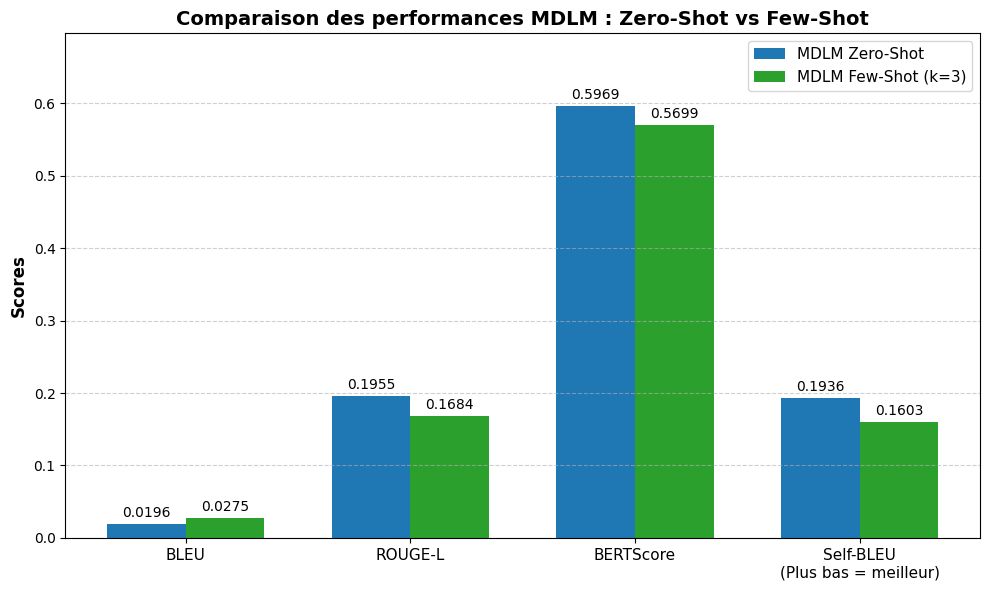

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Les noms de nos métriques
labels = ['BLEU', 'ROUGE-L', 'BERTScore', 'Self-BLEU\n(Plus bas = meilleur)']

# On récupère les valeurs depuis les variables en mémoire de la cellule précédente
zero_shot_scores = [metrics_zs["BLEU"], metrics_zs["ROUGE-L"], metrics_zs["BERTScore"], self_bleu_zs]
few_shot_scores  = [metrics_fs["BLEU"], metrics_fs["ROUGE-L"], metrics_fs["BERTScore"], self_bleu_fs]

x = np.arange(len(labels))  # Position des labels sur l'axe X
width = 0.35  # Largeur des barres

# Création de la figure
fig, ax = plt.subplots(figsize=(10, 6))

# Dessin des barres (Bleu pour Zero-shot, Vert pour Few-shot)
rects1 = ax.bar(x - width/2, zero_shot_scores, width, label='MDLM Zero-Shot', color='#1f77b4')
rects2 = ax.bar(x + width/2, few_shot_scores, width, label='MDLM Few-Shot (k=3)', color='#2ca02c')

# Personnalisation du graphique
ax.set_ylabel('Scores', fontsize=12, fontweight='bold')
ax.set_title('Comparaison des performances MDLM : Zero-Shot vs Few-Shot', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)

# On ajuste la hauteur de l'axe Y pour laisser de la place aux textes au-dessus des barres
ax.set_ylim(0, max(max(zero_shot_scores), max(few_shot_scores)) + 0.1)

# Ajout d'une grille horizontale pour faciliter la lecture
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Ajout des valeurs exactes au-dessus des barres
ax.bar_label(rects1, fmt='%.4f', padding=3, fontsize=10)
ax.bar_label(rects2, fmt='%.4f', padding=3, fontsize=10)

fig.tight_layout()

# Sauvegarde et Affichage
# On sauvegarde le graphique en haute qualité sur ton Drive
plt.savefig('/content/drive/MyDrive/genai/comparaison_results/graphique_mdlm_comparaison.png', dpi=300)
print("Graphique sauvegardé sur le Google Drive (graphique_mdlm_comparaison.png)")

plt.show()

#### Radar chart for metrics comparison (Zero-shot vs Few-shot)

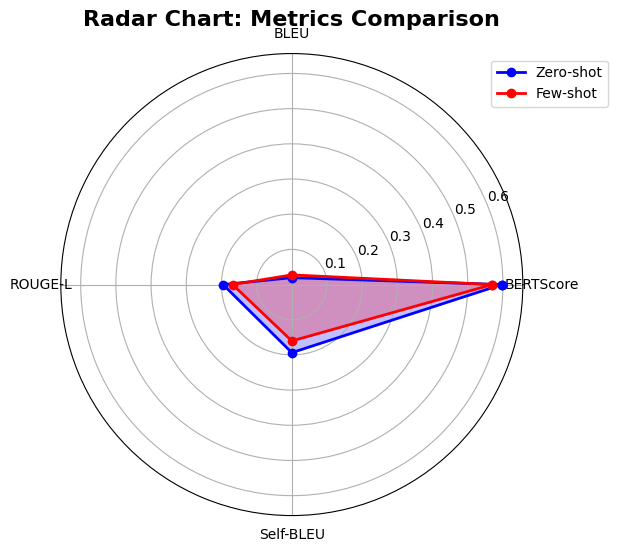

In [ ]:
# Radar chart: on utilise les métriques calculées précédemment
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# Categories
categories = ['BERTScore', 'BLEU', 'ROUGE-L', 'Self-BLEU']
N = len(categories)

# Values (attend que metrics_zs, metrics_fs et self_bleu_* existent)
values_zs = [metrics_zs['BERTScore'], metrics_zs['BLEU'], metrics_zs['ROUGE-L'], self_bleu_zs]
values_fs = [metrics_fs['BERTScore'], metrics_fs['BLEU'], metrics_fs['ROUGE-L'], self_bleu_fs]

# Close the loop for radar
values_zs += values_zs[:1]
values_fs += values_fs[:1]

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='polar'))

ax.plot(angles, values_zs, 'o-', linewidth=2, label='Zero-shot', color='blue')
ax.fill(angles, values_zs, alpha=0.25, color='blue')

ax.plot(angles, values_fs, 'o-', linewidth=2, label='Few-shot', color='red')
ax.fill(angles, values_fs, alpha=0.25, color='red')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, max(max(values_zs[:-1]), max(values_fs[:-1])) * 1.1)
ax.set_title('Radar Chart: Metrics Comparison', size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))

plt.show()

#### Boxplots: distribution des BLEU et ROUGE-L pour Zero-shot vs Few-shot

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

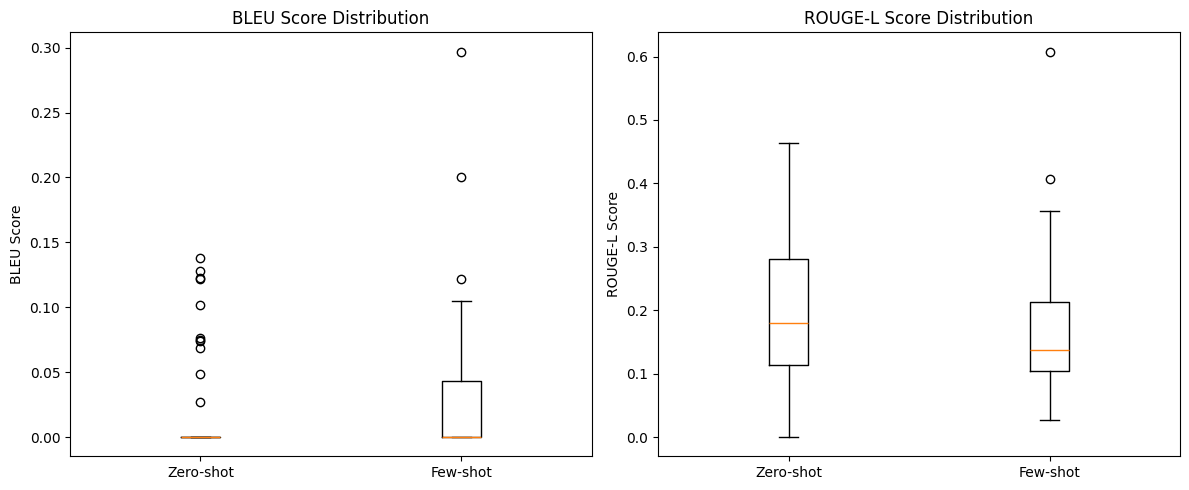

In [ ]:
# Boxplot pour BLEU et ROUGE-L
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu
from nltk import word_tokenize
import matplotlib.pyplot as plt

# Préparer les prédictions plates (premier échantillon par exemple)
flat_preds_zs = [p[0] for p in predictions_zs]
flat_preds_fs = [p[0] for p in predictions_fs]
flat_refs = [r[0] for r in references]

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
bleu_weights = (0.25, 0.25, 0.25, 0.25)

individual_bleu_zs = []
individual_rouge_zs = []
individual_bleu_fs = []
individual_rouge_fs = []

for pred, ref in zip(flat_preds_zs, flat_refs):
    try:
        bleu = sentence_bleu([word_tokenize(ref)], word_tokenize(pred), weights=bleu_weights)
    except ZeroDivisionError:
        bleu = 0.0
    individual_bleu_zs.append(bleu)
    rouge_score = scorer.score(ref, pred)['rougeL'].fmeasure
    individual_rouge_zs.append(rouge_score)

for pred, ref in zip(flat_preds_fs, flat_refs):
    try:
        bleu = sentence_bleu([word_tokenize(ref)], word_tokenize(pred), weights=bleu_weights)
    except ZeroDivisionError:
        bleu = 0.0
    individual_bleu_fs.append(bleu)
    rouge_score = scorer.score(ref, pred)['rougeL'].fmeasure
    individual_rouge_fs.append(rouge_score)

# Affichage des boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([individual_bleu_zs, individual_bleu_fs], labels=['Zero-shot', 'Few-shot'])
axes[0].set_title('BLEU Score Distribution')
axes[0].set_ylabel('BLEU Score')

axes[1].boxplot([individual_rouge_zs, individual_rouge_fs], labels=['Zero-shot', 'Few-shot'])
axes[1].set_title('ROUGE-L Score Distribution')
axes[1].set_ylabel('ROUGE-L Score')

plt.tight_layout()
plt.show()

#### Exemples : aperçu des premières entrées (Reference / Pred Zero-shot / Pred Few-shot)

In [ ]:
import pandas as pd

# Afficher les 10 premiers exemples pour inspection qualitative
num_examples = 10
examples_data = []
for i in range(min(num_examples, len(subset_eval))):
    example = subset_eval[i]
    pred_zs = predictions_zs[i][0] if i < len(predictions_zs) else 'N/A'
    pred_fs = predictions_fs[i][0] if i < len(predictions_fs) else 'N/A'
    examples_data.append({
        'Table': example.get('serialized_table','')[:200] + ('...' if len(example.get('serialized_table',''))>200 else ''),
        'Reference': example.get('reference',''),
        'Pred Zero-Shot': pred_zs,
        'Pred Few-Shot': pred_fs
    })

df_examples = pd.DataFrame(examples_data)
df_examples

,Table,Reference,Pred Zero-Shot,Pred Few-Shot
0,# : 76 | Took Office : Daniel Henry Chamberlai...,Daniel Henry Chamberlain was the 76th Governor...,"Daniel 76, a former Chamberlain, served as th...","Daniel 6lain, the head of of the British Army,..."
1,Year : 2016 | Title : Kids in Love | Role : Ev...,Alma Jodorowsky had the role of Evelyn in 2016...,"In "" 2 Love Love"" (2204), the isabella plays t...",Eynyn Lovejoy a role role in the in in Love fi...
2,TOTAL : 119,"In his rookie season, Hawk led with 119 total ...","The table shows the 1919 British Census, which...","The total score 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,Name : Peter II the Simple (Pêr II) 1450–1457 ...,"At the very end of his life, Arthur III became...","Peter II the the Simple, Pêr II, 1450–1457, a ...",Peter II the the Simple (Pêr II) was a of the...
4,Speaker : Ralph J. Parker,Ralph J. Parker was a Minnesota politician and...,"Ralph J. Parker is a renowned actor,,, and,,, ...",Ralph J. Parker was a prominent figure in the ...
5,Year : 2016 | Host City : Da Nang | Host Natio...,"The last Asian Beach Games was held in Danang,...","The 2016 event, held in Da Nangang, Vietnam, b...",The 2016-2020 Vietnam2020 World Music Festival...
6,Year : 2012 | Title : Person of Interest | Rol...,"In 2012, Julian Sands played as Alistair Wesle...","The 22nd episode episode of the TV series ""Per...","The 122nd episode of the show of 2012, "" of of..."
7,Year : 2005 | Title : Coach Carter | Role : Do...,"In 2005, Adrienne Bailon starred in Coach Cart...","In 2205, the Coach Carter Carter, the head of ...","In 220,,,000,0,,0,000,,,0,000,,00,000,,,0,000,..."
8,Name : John L. Estrada,John Learie Estrada is the United States Ambas...,"John L. Estrada is a retired American soldier,...",John L. Estrada is a British actor who for for...
9,GP : 32 | RPG : 4.8 | APG : 2.3 | PPG : 23.5,"Trey Johnson averaged 23.5 points, 4.8 rebound...",The table provided a summary of the player's g...,"The table provides the Gameplay, Name, Age, GP..."


#### Radar chart for metrics comparison (Zero-shot vs Few-shot)

#### Exemples : aperçu des premières entrées (Reference / Pred Zero-shot / Pred Few-shot)

In [ ]:
import pandas as pd

# Afficher les 10 premiers exemples pour inspection qualitative
num_examples = 10
examples_data = []
for i in range(min(num_examples, len(subset_eval))):
    example = subset_eval[i]
    pred_zs = predictions_zs[i][0] if i < len(predictions_zs) else 'N/A'
    pred_fs = predictions_fs[i][0] if i < len(predictions_fs) else 'N/A'
    examples_data.append({
        'Table': example.get('serialized_table','')[:200] + ('...' if len(example.get('serialized_table',''))>200 else ''),
        'Reference': example.get('reference',''),
        'Pred Zero-Shot': pred_zs,
        'Pred Few-Shot': pred_fs
    })

df_examples = pd.DataFrame(examples_data)
df_examples

,Table,Reference,Pred Zero-Shot,Pred Few-Shot
0,# : 76 | Took Office : Daniel Henry Chamberlai...,Daniel Henry Chamberlain was the 76th Governor...,"Daniel 76, a former Chamberlain, served as th...","Daniel 6lain, the head of of the British Army,..."
1,Year : 2016 | Title : Kids in Love | Role : Ev...,Alma Jodorowsky had the role of Evelyn in 2016...,"In "" 2 Love Love"" (2204), the isabella plays t...",Eynyn Lovejoy a role role in the in in Love fi...
2,TOTAL : 119,"In his rookie season, Hawk led with 119 total ...","The table shows the 1919 British Census, which...","The total score 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,Name : Peter II the Simple (Pêr II) 1450–1457 ...,"At the very end of his life, Arthur III became...","Peter II the the Simple, Pêr II, 1450–1457, a ...",Peter II the the Simple (Pêr II) was a of the...
4,Speaker : Ralph J. Parker,Ralph J. Parker was a Minnesota politician and...,"Ralph J. Parker is a renowned actor,,, and,,, ...",Ralph J. Parker was a prominent figure in the ...
5,Year : 2016 | Host City : Da Nang | Host Natio...,"The last Asian Beach Games was held in Danang,...","The 2016 event, held in Da Nangang, Vietnam, b...",The 2016-2020 Vietnam2020 World Music Festival...
6,Year : 2012 | Title : Person of Interest | Rol...,"In 2012, Julian Sands played as Alistair Wesle...","The 22nd episode episode of the TV series ""Per...","The 122nd episode of the show of 2012, "" of of..."
7,Year : 2005 | Title : Coach Carter | Role : Do...,"In 2005, Adrienne Bailon starred in Coach Cart...","In 2205, the Coach Carter Carter, the head of ...","In 220,,,000,0,,0,000,,,0,000,,00,000,,,0,000,..."
8,Name : John L. Estrada,John Learie Estrada is the United States Ambas...,"John L. Estrada is a retired American soldier,...",John L. Estrada is a British actor who for for...
9,GP : 32 | RPG : 4.8 | APG : 2.3 | PPG : 23.5,"Trey Johnson averaged 23.5 points, 4.8 rebound...",The table provided a summary of the player's g...,"The table provides the Gameplay, Name, Age, GP..."


# Manual Evaluation

## Manual Evaluation - Zero-Shot (k=0)

In [ ]:
def build_manual_faithfulness_df(examples, predictions, n_samples=50):
    """
    Construit un dataframe pour analyse manuelle de la fidélité.

    IMPORTANT: Chaque ligne du dataframe = 1 exemple unique
    Les 3 prédictions (déterministe + 2 samples) sont dans des colonnes séparées.

    Args:
        examples: Liste d'exemples (chaque ex a "serialized_table" et "reference")
        predictions: Liste de listes [[pred1, pred2, pred3], ...] pour chaque exemple
        n_samples: Nombre d'exemples à inclure (max 50 pour évaluation manuelle)

    Returns:
        DataFrame avec colonnes: table, reference, pred_1, pred_2, pred_3
    """

    rows = []

    # Vérification de la cohérence entre exemples et prédictions
    n = min(n_samples, len(examples), len(predictions))

    if len(examples) != len(predictions):
        print(f"  ATTENTION: Nombre d'exemples ({len(examples)}) != nombre de prédictions ({len(predictions)})")
        print(f"   On utilisera min({len(examples)}, {len(predictions)}) = {n} exemples")

    for i in range(n):
        ex = examples[i]
        preds = predictions[i]

        # Vérification que chaque exemple a au moins 3 prédictions
        if len(preds) < 3:
            print(f"  Exemple {i}: seulement {len(preds)} prédiction(s), attendu 3")

        # Construction de la ligne
        row = {
            "idx": i,  # Index pour pouvoir tracer la source
            "table": ex["serialized_table"],
            "reference": ex["reference"],
            "pred_1 (deterministic)": preds[0] if len(preds) > 0 else "[MISSING]",
            "pred_2 (sampled)": preds[1] if len(preds) > 1 else "[MISSING]",
            "pred_3 (sampled)": preds[2] if len(preds) > 2 else "[MISSING]"
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    print(f" DataFrame construit: {len(df)} lignes (exemples uniques)")
    print(f"   Chaque ligne = 1 exemple avec sa table, référence, et 3 prédictions")

    return df


In [ ]:
df_mdlm = build_manual_faithfulness_df(
    subset_eval,        # Données de test (50 exemples)
    predictions_zs,     # Prédictions Zero-Shot générées précédemment
    n_samples=50
)

 DataFrame construit: 50 lignes (exemples uniques)
   Chaque ligne = 1 exemple avec sa table, référence, et 3 prédictions


In [ ]:
pd.set_option('display.max_colwidth', None)

df_mdlm.head(10)

,idx,table,reference,pred_1 (deterministic),pred_2 (sampled),pred_3 (sampled)
0,0,"# : 76 | Took Office : Daniel Henry Chamberlain | Left Office : December 1, 1874",Daniel Henry Chamberlain was the 76th Governor of South Carolina from 1874.,"Daniel 76, a former Chamberlain, served as the Secretary of the House of of Commons in 1874, until his left office on December 1, 1874. The Chamberlain was known for his role in managing the House of the Commons, the largest legislative body of the United States\n.","# 76, the predecessor of Daniel Henry Chamberlain, took his office on December 1, 1874, serving as the Secretary of the House of the Chamberlain House, and. Chamberlain, however, on, 15th, 1874, resigned from his position, resign to the position of the Secretary of the House of the Chamberlain House and and subsequently to the Secretary of the House of the Chamberlain House..","Daniel 7676, the Earl of of Chamberlain, was appointed as Prime Lord on December 1774, his term ended on December 16th, 1874. He was appointed as the Prime Lord on December 1774, and his term ended on December 16th, 1874."
1,1,Year : 2016 | Title : Kids in Love | Role : Evelyn,Alma Jodorowsky had the role of Evelyn in 2016 film Kids in Love.,"In "" 2 Love Love"" (2204), the isabella plays the role of the young girl,, love, and, love,,,, love,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,, love,, love, and, love,","In the ""2 in Love"" film, 201, 2016, played the role of Evelyn, a young girl who is,,, and, and,, and,,, and,, and,, and,, and,,, and, and,, and,, and,, and, and, and,, and, and, and and, and, and, and, and, and, and, and, and, and, and, and, and, and.","Inevil2 Kids in Love is a 20, 2012 film film directed by and,, and, and, starring by, and, and, and, and, and, and, and, and, and, and,,, and, and,, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and."
2,2,TOTAL : 119,"In his rookie season, Hawk led with 119 total tackles.","The table shows the 1919 British Census, which the total population was 119,00 men, boys, children, children, and women. The breakdown of the categories was: 1, 2, 3, 4, 5, and women, with 11,,000 men and 11,,000 boys, respectively,\n.",The table contains 19 19 19 1919 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19.,"The table contains 119 numbers, which are: 1, 1, 2, 3, 4, 4, 5, 5, 6, 7, 8, 9, 10, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112."
3,3,Name : Peter II the Simple (Pêr II) 1450–1457 | Name : Arthur III the Justicier (Arzhur III) 1457–1458 | Death : 26 December 1458 Nantes aged 65,"At the very end of his life, Arthur III became duke of Brittany, succeeding Peter II.","Peter II the the Simple, Pêr II, 1450–1457, a the son of the the Justicier, Ar14icier, Ar14icier, and the son of the Justicier, 14icier, Ar14icier, Ar14icier, Ar14icier, died on 26 December 1458 at Nantes aged 65.","The II the the Simple, Peter IIr, lived 1450-1457 and was Arthur II II the Justic II II II the Justicier, Arzhur III, who 1457-1458 II II II II Justic II Justicier, Nantur, died on 26 December 1458, aged 65.","Peter II, the Simple, also known as Peter the Pêrier (Pêr II) 1450–1457, was a member of Cast Spain who ruled the city of England from 1450 to 1457. Arthur III, the Justicier, also known as Arthur the Arzhurier (Arzhur III) 1457–1458, passed away on 26 December 1458 at 65."
4,4,Speaker : Ralph J. Parker,Ralph J. Parker was a Minnesota politician and a Speaker of the Minnesota House of Representatives.,"Ralph J. Parker is a renowned actor,,, and,,, comedian,,,, actor,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,, comedian, comedian, .","Ralph J. Parker is a renowned actor, author, and author, known for his work, ""The Life of"" (1190s), which is the first film of the Life of the Rings. Parker is also known for his boo

In [ ]:
# Vérification et diagnostic de la qualité des prédictions

print("=" * 80)
print("DIAGNOSTIC: Vérification des prédictions (Diversité & Répétitions)")
print("=" * 80)

# 1. Vérifier si les 3 prédictions sont différentes pour chaque exemple
repetitions_count = 0
identical_pairs = []

for i in range(len(predictions_zs)):
    preds = predictions_zs[i]

    # Cas 1: pred_1 == pred_2
    if len(preds) > 1 and preds[0] == preds[1]:
        repetitions_count += 1
        identical_pairs.append((i, "pred_1 == pred_2"))

    # Cas 2: pred_2 == pred_3
    if len(preds) > 2 and preds[1] == preds[2]:
        repetitions_count += 1
        identical_pairs.append((i, "pred_2 == pred_3"))

    # Cas 3: pred_1 == pred_3
    if len(preds) > 2 and preds[0] == preds[2]:
        repetitions_count += 1
        identical_pairs.append((i, "pred_1 == pred_3"))

print(f"\n Nombre de cas de répétition identifiée: {repetitions_count}")
if identical_pairs:
    print(f"   Exemples avec prédictions dupliquées:")
    for ex_idx, case in identical_pairs[:10]:  # Affiche max 10
        print(f"      - Exemple {ex_idx}: {case}")

# 2. Longueur des prédictions
pred_lengths = [[len(p) for p in preds] for preds in predictions_zs]
print(f"\n Longueur moyenne des prédictions:")
print(f"   Pred_1: {np.mean([p[0] for p in pred_lengths]):.1f} caractères")
if any(len(p) > 1 for p in pred_lengths):
    print(f"   Pred_2: {np.mean([p[1] for p in pred_lengths if len(p) > 1]):.1f} caractères")
if any(len(p) > 2 for p in pred_lengths):
    print(f"   Pred_3: {np.mean([p[2] for p in pred_lengths if len(p) > 2]):.1f} caractères")

# 3. Vérifier la taille du dataset
print(f"\n Taille du dataset:")
print(f"   Nombre d'exemples: {len(subset_eval) if 'examples' in dir() else 'N/A'}")
print(f"   Nombre de prédictions générées: {len(predictions_zs)}")
print(f"   Taille du dataframe manuel: {len(df_mdlm)}")

print("\n" + "=" * 80)


DIAGNOSTIC: Vérification des prédictions (Diversité & Répétitions)

 Nombre de cas de répétition identifiée: 3
   Exemples avec prédictions dupliquées:
      - Exemple 38: pred_1 == pred_2
      - Exemple 38: pred_2 == pred_3
      - Exemple 38: pred_1 == pred_3

 Longueur moyenne des prédictions:
   Pred_1: 302.7 caractères
   Pred_2: 324.1 caractères
   Pred_3: 317.9 caractères

 Taille du dataset:
   Nombre d'exemples: N/A
   Nombre de prédictions générées: 50
   Taille du dataframe manuel: 50



In [ ]:
os.makedirs("/content/drive/MyDrive/genai/manual_evaluation", exist_ok=True)
output_csv = "/content/drive/MyDrive/genai/manual_evaluation/manual_faithfulness_mdlm.csv"

df_mdlm.to_csv(output_csv, index=False)

print(f"Fichier sauvegardé : {output_csv}")

Fichier sauvegardé : /content/drive/MyDrive/genai/manual_evaluation/manual_faithfulness_mdlm.csv


In [ ]:
# Export avancé: CSV avec colonnes pour annotation manuelle

def create_annotation_csv(df, output_path):
    """
    Crée un CSV augmenté avec des colonnes vides pour l'annotation manuelle.
    Permet d'évaluer: Fidélité, Fluence, Complétude pour chaque prédiction.
    """

    # Créer une version simplifiée avec tables tronquées (pour lisibilité en Excel)
    df_export = df.copy()
    df_export['table_truncated'] = df_export['table'].str[:200] + "..."

    # Ajouter des colonnes pour annotation (à remplir manuellement)
    df_export['pred_1_faithfulness (0-5)'] = ""
    df_export['pred_2_faithfulness (0-5)'] = ""
    df_export['pred_3_faithfulness (0-5)'] = ""
    df_export['notes'] = ""

    # Sélectionner les colonnes à exporter
    export_cols = [
        'idx', 'table_truncated', 'reference',
        'pred_1 (deterministic)', 'pred_1_faithfulness (0-5)',
        'pred_2 (sampled)', 'pred_2_faithfulness (0-5)',
        'pred_3 (sampled)', 'pred_3_faithfulness (0-5)',
        'notes'
    ]
    df_export_final = df_export[export_cols]

    # Sauvegarder
    df_export_final.to_csv(output_path, index=False, encoding='utf-8')

    print(f"   CSV d'annotation créé: {output_path}")
    print(f"   Colonnes: idx, table_truncated, reference, pred_1, pred_1_score, pred_2, pred_2_score, pred_3, pred_3_score, notes")
    print(f"   À remplir: Donnez un score de fidélité (0=complètement faux, 5=parfaitement fidèle)")

    return df_export_final

# Créer et sauvegarder le CSV d'annotation
annotation_csv_path = "/content/drive/MyDrive/genai/manual_evaluation/manual_annotation_mdlm.csv"
df_annotation = create_annotation_csv(df_mdlm, annotation_csv_path)

print(f"\n Aperçu des colonnes d'annotation:")
print(df_annotation[['idx', 'reference', 'pred_1 (deterministic)', 'pred_1_faithfulness (0-5)']].head())


   CSV d'annotation créé: /content/drive/MyDrive/genai/manual_evaluation/manual_annotation_mdlm.csv
   Colonnes: idx, table_truncated, reference, pred_1, pred_1_score, pred_2, pred_2_score, pred_3, pred_3_score, notes
   À remplir: Donnez un score de fidélité (0=complètement faux, 5=parfaitement fidèle)

 Aperçu des colonnes d'annotation:
   idx  \
0    0   
1    1   
2    2   
3    3   
4    4   

                                                                                             reference  \
0                          Daniel Henry Chamberlain was the 76th Governor of South Carolina from 1874.   
1                                    Alma Jodorowsky had the role of Evelyn in 2016 film Kids in Love.   
2                                               In his rookie season, Hawk led with 119 total tackles.   
3                At the very end of his life, Arthur III became duke of Brittany, succeeding Peter II.   
4  Ralph J. Parker was a Minnesota politician and a Speaker of the M

In [ ]:
# Affichage formaté pour évaluation manuelle (Lisible & Explorable)

def display_formatted_examples(df, num_examples=10):
    """
    Affiche les exemples dans un format lisible pour évaluation manuelle.
    Chaque exemple occupe plusieurs lignes pour éviter la troncature.
    """
    print("\n" + "="*100)
    print("ÉVALUATION MANUELLE: Fidélité des prédictions MDLM (Zero-Shot)")
    print("="*100 + "\n")

    for idx in range(min(num_examples, len(df))):
        row = df.iloc[idx]

        print(f"▶ EXEMPLE {idx + 1} (Index: {row['idx']})")
        print("-" * 100)

        # Afficher la table (tronquée à 250 caractères)
        table_text = row['table']
        table_display = table_text[:250] + "..." if len(table_text) > 250 else table_text
        print(f" TABLE:")
        print(f"   {table_display}\n")

        # Afficher la référence
        print(f" RÉFÉRENCE (Gold Standard):")
        print(f"   {row['reference']}\n")

        # Afficher les 3 prédictions
        print(f" PRÉDICTIONS MDLM:")
        print(f"   [1] Déterministe (T=0.0):  {row['pred_1 (deterministic)']}")
        print(f"   [2] Samplé       (T=0.5):  {row['pred_2 (sampled)']}")
        print(f"   [3] Samplé       (T=0.5):  {row['pred_3 (sampled)']}\n")

        # Analyse rapide
        unique_preds = len(set([row['pred_1 (deterministic)'],
                                row['pred_2 (sampled)'],
                                row['pred_3 (sampled)']]))
        diversity = " DIVERSE" if unique_preds == 3 else "  RÉPÉTITIF"
        print(f" Diversité: {diversity} ({unique_preds}/3 prédictions uniques)")

        print("\n" + "="*100 + "\n")

# Afficher les 10 premiers exemples
display_formatted_examples(df_mdlm, num_examples=10)



ÉVALUATION MANUELLE: Fidélité des prédictions MDLM (Zero-Shot)

▶ EXEMPLE 1 (Index: 0)
----------------------------------------------------------------------------------------------------
 TABLE:
   # : 76 | Took Office : Daniel Henry Chamberlain | Left Office : December 1, 1874

 RÉFÉRENCE (Gold Standard):
   Daniel Henry Chamberlain was the 76th Governor of South Carolina from 1874.

 PRÉDICTIONS MDLM:
   [1] Déterministe (T=0.0):  Daniel  76, a former Chamberlain, served as the Secretary of the House of of Commons in 1874, until his left office on December 1, 1874. The Chamberlain was known for his role in managing the House of the Commons, the largest legislative body of the United States
.
   [2] Samplé       (T=0.5):  #  76, the predecessor of Daniel Henry Chamberlain, took his office on December 1, 1874, serving as the Secretary of the House of the Chamberlain House, and. Chamberlain, however, on, 15th, 1874, resigned from his position, resign to the position of the Secretary o

## Manual Evaluation - Few-Shot (k=3)

In [ ]:
import pandas as pd

def build_manual_faithfulness_df_fewshot(examples, predictions, n_samples=50):
    """
    Construit un dataframe pour analyse manuelle de la fidélité (Few-Shot).

    IMPORTANT: Chaque ligne du dataframe = 1 exemple unique
    Les 3 prédictions (déterministe + 2 samples) sont dans des colonnes séparées.

    Args:
        examples: Liste d'exemples (chaque ex a "serialized_table" et "reference")
        predictions: Liste de listes [[pred1, pred2, pred3], ...] pour chaque exemple
        n_samples: Nombre d'exemples à inclure (max 50 pour évaluation manuelle)

    Returns:
        DataFrame avec colonnes: table, reference, pred_1, pred_2, pred_3
    """

    rows = []

    # Vérification de la cohérence entre exemples et prédictions
    n = min(n_samples, len(examples), len(predictions))

    if len(examples) != len(predictions):
        print(f"  ATTENTION: Nombre d'exemples ({len(examples)}) != nombre de prédictions ({len(predictions)})")
        print(f"   On utilisera min({len(examples)}, {len(predictions)}) = {n} exemples")

    for i in range(n):
        ex = examples[i]
        preds = predictions[i]

        # Vérification que chaque exemple a au moins 3 prédictions
        if len(preds) < 3:
            print(f"  Exemple {i}: seulement {len(preds)} prédiction(s), attendu 3")

        # Construction de la ligne
        row = {
            "idx": i,  # Index pour pouvoir tracer la source
            "table": ex["serialized_table"],
            "reference": ex["reference"],
            "pred_1 (deterministic)": preds[0] if len(preds) > 0 else "[MISSING]",
            "pred_2 (sampled)": preds[1] if len(preds) > 1 else "[MISSING]",
            "pred_3 (sampled)": preds[2] if len(preds) > 2 else "[MISSING]"
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    print(f" DataFrame construit: {len(df)} lignes (exemples uniques)")
    print(f"   Chaque ligne = 1 exemple avec sa table, référence, et 3 prédictions (Few-Shot k=3)")

    return df

df_mdlm_fs = build_manual_faithfulness_df_fewshot(
    subset_eval,
    predictions_fs,
    n_samples=50
)


 DataFrame construit: 50 lignes (exemples uniques)
   Chaque ligne = 1 exemple avec sa table, référence, et 3 prédictions (Few-Shot k=3)


In [ ]:
pd.set_option('display.max_colwidth', None)

df_mdlm_fs.head(10)


,idx,table,reference,pred_1 (deterministic),pred_2 (sampled),pred_3 (sampled)
0,0,"# : 76 | Took Office : Daniel Henry Chamberlain | Left Office : December 1, 1874",Daniel Henry Chamberlain was the 76th Governor of South Carolina from 1874.,"Daniel 6lain, the head of of the British Army,, was the commander of 76, the rank of the Army, in 1874, and left office office December 1,1874. On 11 December 1, 1874, Daniel 6lain was appointed to the rank of the76, the rank of the Army, and the head of the Army. In 1875, Daniel 6lain became the head of the U.S...","The Chamberlain family, which included the 76th Daniel Henry wholain took office on December 1 11 11874, left left office on December 11 11 18874, or 11 11 18874, or 11 11 18874. 16 Henry Chamberlainlain left office on December 11 11 18874, or 11 11 18874.","Daniel Henry 76 was the of of the of the of, who left office on December 1, 1874, as the of of the of of the of of the of the of the of the of of the of of the of the of the of the the of the of the the of the of the the of the the of the the the the of the the of the the the the the the the the the the the the the the the the the the the the the the the the the."
1,1,Year : 2016 | Title : Kids in Love | Role : Evelyn,Alma Jodorowsky had the role of Evelyn in 2016 film Kids in Love.,"Eynyn Lovejoy a role role in the in in Love film22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,22","Evelyn Love is a role in the film ""Kids in Love,"" which was released in 2016, starring the characters of, and,, and, and,, and,, and,,,, and, and, and, and, and,, and,, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and.",Theynyn Lovejoy theynyn theynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynynyn
2,2,TOTAL : 119,"In his rookie season, Hawk led with 119 total tackles.","The total score 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, scored.","The sequence of the numbers 0, 0,1,1,2,2,2, 3, 3, 4, 5, 5, 6, 6, 7, 7, 8, 9, 9, 9, 10, 10, 11, 11, 12, 12, 13, 13, 13, 14, 14, 15, 15, totals 19.","The total number of primes numbers the numbers 1, 2, 3, 4, 6, 8, 9, 100, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 29, 31, 37, 41, 43, 47, 53, 53, 69."
3,3,Name : Peter II the Simple (Pêr II) 1450–1457 | Name : Arthur III the Justicier (Arzhur III) 1457–1458 | Death : 26 December 1458 Nantes aged 65,"At the very end of his life, Arthur III became duke of Brittany, succeeding Peter II.","Peter II the the Simple (Pêr II) was a of the House of II, 1450–1457, and was the of the House of of III, 1457–1458, and Arthur III the the Justicier (Arzhur III) was the of the House of III, 1457–1458, and died 26 December 1458 Nantes of 65.","Peter II the the Simple (Pêr II) was a king of Portugal 1450–1457, while Arthur III the Justicier (Arzhur III) was a king of Spain 1457–1458. Peter II II II II passed away on December 24, 1458, at the age of 63, and Arthur Arzhic III passed away on December 2, 1458 in Nantes at the age of 65.","Arthur II II the Justicier (Arzhur III) 1457–1148 (also known as III 1457–1458) was born on the day 1 II1457, like Peterr II (Pêr II) 1450–1457, who was born on the day 1 II1450. He was at at 5 65 and passed away on 26 December 1468.."
4,4,Speaker : Ralph J. Parker,Ralph J. Parker was a Minnesota politician and a Speaker of the Minnesota House of Representatives.,"Ralph J. Parker was a prominent figure in the United of America, the United States the, and the United Kingdom, and the the United of the the United, the the United, the United, the United United United United United United United United United United United United United United United United United United United

In [ ]:
# Vérification et diagnostic de la qualité des prédictions (Few-Shot)

print("=" * 80)
print("DIAGNOSTIC: Vérification des prédictions Few-Shot (Diversité & Répétitions)")
print("=" * 80)

# 1. Vérifier si les 3 prédictions sont différentes pour chaque exemple
repetitions_count_fs = 0
identical_pairs_fs = []

for i in range(len(predictions_fs)):
    preds = predictions_fs[i]

    # Cas 1: pred_1 == pred_2
    if len(preds) > 1 and preds[0] == preds[1]:
        repetitions_count_fs += 1
        identical_pairs_fs.append((i, "pred_1 == pred_2"))

    # Cas 2: pred_2 == pred_3
    if len(preds) > 2 and preds[1] == preds[2]:
        repetitions_count_fs += 1
        identical_pairs_fs.append((i, "pred_2 == pred_3"))

    # Cas 3: pred_1 == pred_3
    if len(preds) > 2 and preds[0] == preds[2]:
        repetitions_count_fs += 1
        identical_pairs_fs.append((i, "pred_1 == pred_3"))

print(f"\n Nombre de cas de répétition identifiée: {repetitions_count_fs}")
if identical_pairs_fs:
    print(f"   Exemples avec prédictions dupliquées:")
    for ex_idx, case in identical_pairs_fs[:10]:  # Affiche max 10
        print(f"      - Exemple {ex_idx}: {case}")

# 2. Longueur des prédictions
pred_lengths_fs = [[len(p) for p in preds] for preds in predictions_fs]
print(f"\n Longueur moyenne des prédictions (Few-Shot):")
print(f"   Pred_1: {np.mean([p[0] for p in pred_lengths_fs]):.1f} caractères")
if any(len(p) > 1 for p in pred_lengths_fs):
    print(f"   Pred_2: {np.mean([p[1] for p in pred_lengths_fs if len(p) > 1]):.1f} caractères")
if any(len(p) > 2 for p in pred_lengths_fs):
    print(f"   Pred_3: {np.mean([p[2] for p in pred_lengths_fs if len(p) > 2]):.1f} caractères")

# 3. Vérifier la taille du dataset
print(f"\n Taille du dataset (Few-Shot):")
print(f"   Nombre d'exemples: {len(subset_eval)}")
print(f"   Nombre de prédictions générées: {len(predictions_fs)}")
print(f"   Taille du dataframe manuel: {len(df_mdlm_fs)}")

print("\n" + "=" * 80)


DIAGNOSTIC: Vérification des prédictions Few-Shot (Diversité & Répétitions)

 Nombre de cas de répétition identifiée: 0

 Longueur moyenne des prédictions (Few-Shot):
   Pred_1: 339.0 caractères
   Pred_2: 289.3 caractères
   Pred_3: 317.8 caractères

 Taille du dataset (Few-Shot):
   Nombre d'exemples: 50
   Nombre de prédictions générées: 50
   Taille du dataframe manuel: 50



In [ ]:
output_csv_fs = f"{FOLDER_PATH}manual_evaluation/manual_faithfulness_mdlm_fewshot.csv"

df_mdlm_fs.to_csv(output_csv_fs, index=False)

print(f"Fichier sauvegardé : {output_csv_fs}")


Fichier sauvegardé : /content/drive/MyDrive/genai/manual_evaluation/manual_faithfulness_mdlm_fewshot.csv


In [ ]:
# Export avancé: CSV avec colonnes pour annotation manuelle (Few-Shot)

def create_annotation_csv_fewshot(df, output_path):
    """
    Crée un CSV augmenté avec des colonnes vides pour l'annotation manuelle (Few-Shot).
    Permet d'évaluer: Fidélité, Fluence, Complétude pour chaque prédiction.
    """

    # Créer une version simplifiée avec tables tronquées (pour lisibilité en Excel)
    df_export = df.copy()
    df_export['table_truncated'] = df_export['table'].str[:200] + "..."

    # Ajouter des colonnes pour annotation (à remplir manuellement)
    df_export['pred_1_faithfulness (0-5)'] = ""
    df_export['pred_2_faithfulness (0-5)'] = ""
    df_export['pred_3_faithfulness (0-5)'] = ""
    df_export['notes'] = ""

    # Sélectionner les colonnes à exporter
    export_cols = [
        'idx', 'table_truncated', 'reference',
        'pred_1 (deterministic)', 'pred_1_faithfulness (0-5)',
        'pred_2 (sampled)', 'pred_2_faithfulness (0-5)',
        'pred_3 (sampled)', 'pred_3_faithfulness (0-5)',
        'notes'
    ]
    df_export_final = df_export[export_cols]

    # Sauvegarder
    df_export_final.to_csv(output_path, index=False, encoding='utf-8')

    print(f"   CSV d'annotation créé: {output_path}")
    print(f"   À remplir: Donnez un score de fidélité (0=complètement faux, 5=parfaitement fidèle)")

    return df_export_final

# Créer et sauvegarder le CSV d'annotation pour Few-Shot
annotation_csv_path_fs = f"{FOLDER_PATH}manual_annotation_mdlm_fewshot.csv"
df_annotation_fs = create_annotation_csv_fewshot(df_mdlm_fs, annotation_csv_path_fs)

print(f"\n Aperçu des colonnes d'annotation (Few-Shot):")
print(df_annotation_fs[['idx', 'reference', 'pred_1 (deterministic)', 'pred_1_faithfulness (0-5)']].head())


   CSV d'annotation créé: /content/drive/MyDrive/genai/manual_annotation_mdlm_fewshot.csv
   À remplir: Donnez un score de fidélité (0=complètement faux, 5=parfaitement fidèle)

 Aperçu des colonnes d'annotation (Few-Shot):
   idx  \
0    0   
1    1   
2    2   
3    3   
4    4   

                                                                                             reference  \
0                          Daniel Henry Chamberlain was the 76th Governor of South Carolina from 1874.   
1                                    Alma Jodorowsky had the role of Evelyn in 2016 film Kids in Love.   
2                                               In his rookie season, Hawk led with 119 total tackles.   
3                At the very end of his life, Arthur III became duke of Brittany, succeeding Peter II.   
4  Ralph J. Parker was a Minnesota politician and a Speaker of the Minnesota House of Representatives.   

                                                                              

In [ ]:
# Affichage formaté pour évaluation manuelle - Few-Shot (Lisible & Explorable)

def display_formatted_examples_fewshot(df, num_examples=10):
    """
    Affiche les exemples dans un format lisible pour évaluation manuelle (Few-Shot).
    Chaque exemple occupe plusieurs lignes pour éviter la troncature.
    """
    print("\n" + "="*100)
    print("ÉVALUATION MANUELLE: Fidélité des prédictions MDLM (Few-Shot k=3)")
    print("="*100 + "\n")

    for idx in range(min(num_examples, len(df))):
        row = df.iloc[idx]

        print(f"▶ EXEMPLE {idx + 1} (Index: {row['idx']})")
        print("-" * 100)

        # Afficher la table (tronquée à 250 caractères)
        table_text = row['table']
        table_display = table_text[:250] + "..." if len(table_text) > 250 else table_text
        print(f" TABLE:")
        print(f"   {table_display}\n")

        # Afficher la référence
        print(f" RÉFÉRENCE (Gold Standard):")
        print(f"   {row['reference']}\n")

        # Afficher les 3 prédictions
        print(f" PRÉDICTIONS MDLM (Few-Shot k=3):")
        print(f"   [1] Déterministe (T=0.0):  {row['pred_1 (deterministic)']}")
        print(f"   [2] Samplé       (T=0.5):  {row['pred_2 (sampled)']}")
        print(f"   [3] Samplé       (T=0.5):  {row['pred_3 (sampled)']}\n")

        # Analyse rapide
        unique_preds = len(set([row['pred_1 (deterministic)'],
                                row['pred_2 (sampled)'],
                                row['pred_3 (sampled)']]))
        diversity = " DIVERSE" if unique_preds == 3 else "  RÉPÉTITIF"
        print(f" Diversité: {diversity} ({unique_preds}/3 prédictions uniques)")

        print("\n" + "="*100 + "\n")

# Afficher les 10 premiers exemples Few-Shot
display_formatted_examples_fewshot(df_mdlm_fs, num_examples=10)



ÉVALUATION MANUELLE: Fidélité des prédictions MDLM (Few-Shot k=3)

▶ EXEMPLE 1 (Index: 0)
----------------------------------------------------------------------------------------------------
 TABLE:
   # : 76 | Took Office : Daniel Henry Chamberlain | Left Office : December 1, 1874

 RÉFÉRENCE (Gold Standard):
   Daniel Henry Chamberlain was the 76th Governor of South Carolina from 1874.

 PRÉDICTIONS MDLM (Few-Shot k=3):
   [1] Déterministe (T=0.0):  Daniel 6lain, the head of of the British Army,, was the commander of 76, the rank of the Army, in 1874, and left office office December  1,1874. On 11 December 1, 1874, Daniel 6lain was appointed to the rank of the76, the rank of the Army, and the head of the Army. In 1875, Daniel 6lain became the head of the U.S...
   [2] Samplé       (T=0.5):  The Chamberlain family, which included the 76th Daniel Henry wholain took office on December 1 11 11874, left left office on December 11 11 18874, or 11 11 18874, or 11 11 18874. 16 Henry Chamber

# Fine-Tuning du modèle MDLM

### Approche proposée:
1. Fine-tuning sur le dataset d'entraînement (avec masked language modeling)
2. Évaluation sur le dataset de test (Zero-Shot, Few-Shot, et Fine-Tuned)
3. Analyse comparative des performances (benchmark)
4. Sauvegarde du modèle fine-tuned pour réutilisation future

---



---

### **Types de Fine-Tuning**

1. **Full Fine-Tuning** (ce qu'on fait ici)
   - Réentraîne TOUS les paramètres du modèle
   - Meilleur résultat, mais plus long/coûteux

2. **Parameter-Efficient Fine-Tuning (PEFT)**
   - LoRA, Adapters, Prefix-Tuning
   - Plus rapide, mais résultats légèrement inférieurs

---

### **Processus suivant du Fine-Tuning en 3 Étapes**

```
ÉTAPE 1: Modèle Pré-Entraîné
   ↓ (chargé depuis Hugging Face)
   Modèle MDLM pré-entraîné sur texte générique
   ↓
   
ÉTAPE 2: Réentraînement Spécialisé (fine-tuning)
   ↓ (sur votre dataset ToTTo)
   Ajuste les poids du modèle
   Améliore la compréhension du domaine table-to-text
   ↓
   
ÉTAPE 3: Modèle Fine-Tuned
   ↓ (sauvegardé)
   Nouvelle version spécialisée du modèle
   Meilleure performance sur ToTTo
```

---


In [6]:
# ===== ÉTAPE 1: Préparation des données pour Fine-Tuning =====
# Créer un dataset pour fine-tuner le modèle sur les descriptions ToTTo

from torch.utils.data import Dataset, DataLoader
import json

class ToTTOFinetuneDataset(Dataset):
    """
    Dataset custom pour fine-tuning MDLM sur les descriptions ToTTo.
    Chaque exemple = (table_text + description) en tant que texte complété.
    """
    def __init__(self, examples, tokenizer, max_length=256):
        self.examples = examples
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]

        # Construire le texte complet: Table + Description
        # Format: "Table:\n{table}\n\nDescription: {reference}"
        full_text = f"Table:\n{ex['serialized_table']}\n\nDescription: {ex['reference']}"

        # Tokeniser
        encoding = self.tokenizer(
            full_text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Pour le fine-tuning en MLM (Masked Language Modeling):
        # - input_ids: les tokens avec masques
        # - labels: les tokens à prédire (même que input_ids pour MLM)
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': input_ids.clone()  # Pour MLM, labels = input_ids
        }

# Créer le dataset de fine-tuning
print(" Création du dataset de fine-tuning...")
finetune_dataset = ToTTOFinetuneDataset(
    subset_eval,  # On utilise le dataset d'eval pour démo (idéalement: train_subset complet pour cette valeur)
    tokenizer,
    max_length=256
)

# Créer un DataLoader
BATCH_SIZE_FT = 4  # Réduire si problème de mémoire
finetune_dataloader = DataLoader(
    finetune_dataset,
    batch_size=BATCH_SIZE_FT,
    shuffle=True,
    num_workers=0
)

print(f"   Dataset de fine-tuning créé: {len(finetune_dataset)} exemples")
print(f"   Batch size: {BATCH_SIZE_FT}")
print(f"   Nombre de batches: {len(finetune_dataloader)}")


 Création du dataset de fine-tuning...
   Dataset de fine-tuning créé: 50 exemples
   Batch size: 4
   Nombre de batches: 13


In [7]:
# ===== ÉTAPE 2: Fine-Tuning du modèle MDLM =====

from torch.optim import AdamW
from tqdm import tqdm

def finetune_mdlm(model, dataloader, device, num_epochs=3, learning_rate=5e-5):
    """
    Fine-tune le modèle MDLM en Masked Language Modeling (MLM).

    Args:
        model: Le modèle MDLM à fine-tuner
        dataloader: DataLoader avec les données de fine-tuning
        device: 'cuda' ou 'cpu'
        num_epochs: Nombre d'epochs de fine-tuning
        learning_rate: Learning rate pour l'optimizer

    Returns:
        losses: Liste des pertes par epoch
    """

    # Préparer l'optimizer (utiliser AdamW pour transformer models)
    optimizer = AdamW(model.parameters(), lr=learning_rate)

    # Activer le mode training
    model.train()

    losses = []
    total_loss = 0

    print(f"\n Démarrage du fine-tuning...")
    print(f"   Epochs: {num_epochs}")
    print(f"   Learning rate: {learning_rate}")
    print(f"   Device: {device}\n")

    for epoch in range(num_epochs):
        epoch_loss = 0
        progress_bar = tqdm(finetune_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch_idx, batch in enumerate(progress_bar):
            # Déplacer le batch sur le device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Tracker la loss
            epoch_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})

        # Moyenne de la loss sur l'epoch
        avg_epoch_loss = epoch_loss / len(finetune_dataloader)
        losses.append(avg_epoch_loss)

        print(f"   Epoch {epoch+1}/{num_epochs} - Loss moyen: {avg_epoch_loss:.4f}\n")

    # Revenir en mode eval
    model.eval()

    print(f"   Fine-tuning terminé!")
    print(f"   Loss finale: {losses[-1]:.4f}")

    return losses

# Lancer le fine-tuning
print("=" * 80)
print("FINE-TUNING DU MODÈLE MDLM")
print("=" * 80)

finetune_losses = finetune_mdlm(
    model=model,
    dataloader=finetune_dataloader,
    device=device,
    num_epochs=5,
    learning_rate=5e-5
)

print(f"\n Évolution de la loss pendant le fine-tuning:")
for epoch, loss in enumerate(finetune_losses, 1):
    print(f"   Epoch {epoch}: {loss:.4f}")


FINE-TUNING DU MODÈLE MDLM

 Démarrage du fine-tuning...
   Epochs: 5
   Learning rate: 5e-05
   Device: cuda



Epoch 1/5: 100%|██████████| 13/13 [00:24<00:00,  1.89s/it, loss=0.373]


   Epoch 1/5 - Loss moyen: 1.9759



Epoch 2/5: 100%|██████████| 13/13 [00:26<00:00,  2.01s/it, loss=0.049]


   Epoch 2/5 - Loss moyen: 0.0876



...

   Epoch 3/5 - Loss moyen: 0.0158



Epoch 4/5: 100%|██████████| 13/13 [00:24<00:00,  1.86s/it, loss=0.006]


   Epoch 4/5 - Loss moyen: 0.0073



Epoch 5/5: 100%|██████████| 13/13 [00:25<00:00,  1.95s/it, loss=0.00824]

   Epoch 5/5 - Loss moyen: 0.0052

   Fine-tuning terminé!
   Loss finale: 0.0052

 Évolution de la loss pendant le fine-tuning:
   Epoch 1: 1.9759
   Epoch 2: 0.0876
   Epoch 3: 0.0158
   Epoch 4: 0.0073
   Epoch 5: 0.0052


In [9]:
# ===== ÉTAPE 3: Génération et Évaluation du modèle Fine-Tuned =====

print("\n" + "=" * 80)
print("GÉNÉRATION AVEC LE MODÈLE FINE-TUNED")
print("=" * 80 + "\n")

print(" Génération de descriptions avec le modèle fine-tuned (Zero-Shot)...")
predictions_ft_zs = generate_descriptions_mdlm(
    subset_eval,
    train_data=None,
    few_shot_k=0,
    n_samples=3,
    steps=16,
    temperature=0.5
)

print("\n Génération de descriptions avec le modèle fine-tuned (Few-Shot k=3)...")
predictions_ft_fs = generate_descriptions_mdlm(
    subset_eval,
    train_data=subset_eval,
    few_shot_k=3,
    n_samples=3,
    steps=16,
    temperature=0.5
)





GÉNÉRATION AVEC LE MODÈLE FINE-TUNED

 Génération de descriptions avec le modèle fine-tuned (Zero-Shot)...
Mode : Zero-shot | 50 exemples
  [10/50] 'The table provided shows the performance of a player player,,,, player play...'
  [20/50] 'The 6, the  event, the the the the the the the  the the the the the the the...'
  [30/50] 'The table table represents the  of the the 2188 JGP JGP JGP Junior Junior, ...'
  [40/50] 'The 19 Peace Peace Marathon, held in the the Czechoslovaklovaklovaklovakia,...'
  [50/50] 'The Meadows of Wisconsin, a the club club based United States, was founded ...'

 Génération de descriptions avec le modèle fine-tuned (Few-Shot k=3)...
Mode : Few-shot (k=3) | 50 exemples
  [10/50] 'The  32  ,  the the GP was  4.8,  the RPG was  4.8,  the AP was   2.3, and ...'
  [20/50] 'The 1500 m event in the the the the Olympics Olympics the the the the the t...'
  [30/50] 'The 21stGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPG...'
  [40/50] 'The 1st Peace

NameError: name 'compute_metrics' is not defined

In [12]:
references = [[ex["reference"]] for ex in subset_eval]

print(f" Variable 'references' recréée avec succès!")
print(f"   Nombre de références: {len(references)}")
print(f"   Format: {references[0]}")  # Affiche la première pour vérifier

# Évaluer le modèle fine-tuned
print("\n" + "=" * 80)
print("ÉVALUATION DU MODÈLE FINE-TUNED")
print("=" * 80 + "\n")

print(">>> Résultats Zero-Shot (Fine-Tuned):")
metrics_ft_zs = compute_metrics(predictions_ft_zs, references)
self_bleu_ft_zs = compute_self_bleu(predictions_ft_zs)

print("\n>>> Résultats Few-Shot (Fine-Tuned):")
metrics_ft_fs = compute_metrics(predictions_ft_fs, references)
self_bleu_ft_fs = compute_self_bleu(predictions_ft_fs)

 Variable 'references' recréée avec succès!
   Nombre de références: 50
   Format: ['Daniel Henry Chamberlain was the 76th Governor of South Carolina from 1874.']

ÉVALUATION DU MODÈLE FINE-TUNED

>>> Résultats Zero-Shot (Fine-Tuned):


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

   BLEU         : 0.0064
   ROUGE-1      : 0.1744
   ROUGE-2      : 0.0573
   ROUGE-L      : 0.1419
   BERTScore    : 0.5452
   Self-BLEU    : 0.2635

>>> Résultats Few-Shot (Fine-Tuned):
   BLEU         : 0.0036
   ROUGE-1      : 0.1590
   ROUGE-2      : 0.0423
   ROUGE-L      : 0.1193
   BERTScore    : 0.4992
   Self-BLEU    : 0.2484


 Métriques rechargées avec succès!
   Zero-Shot BLEU: 0.0196
   Few-Shot BLEU: 0.0275

COMPARAISON: PRE-TRAINED vs FINE-TUNED (Zero-Shot & Few-Shot)

 RÉSUMÉ DES PERFORMANCES:

Model                                    BLEU       ROUGE-L    BERTScore    Self-BLEU 
-------------------------------------------------------------------------------------
Pre-trained Zero-Shot                    0.0196     0.1955     0.5969       0.1936    
Pre-trained Few-Shot (k=3)               0.0275     0.1684     0.5699       0.1603    
Fine-Tuned Zero-Shot                     0.0064     0.1419     0.5452       0.2635    
Fine-Tuned Few-Shot (k=3)                0.0036     0.1193     0.4992       0.2484    


/tmp/ipykernel_17448/3304759527.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=0, ha='center', fontsize=9)
/tmp/ipykernel_17448/3304759527.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=0, ha='center', fontsize=9)
/tmp/ipykernel_17448/3304759527.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=0, ha='center', fontsize=9)
/tmp/ipykernel_17448/3304759527.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=0, ha='center', fontsize=9)


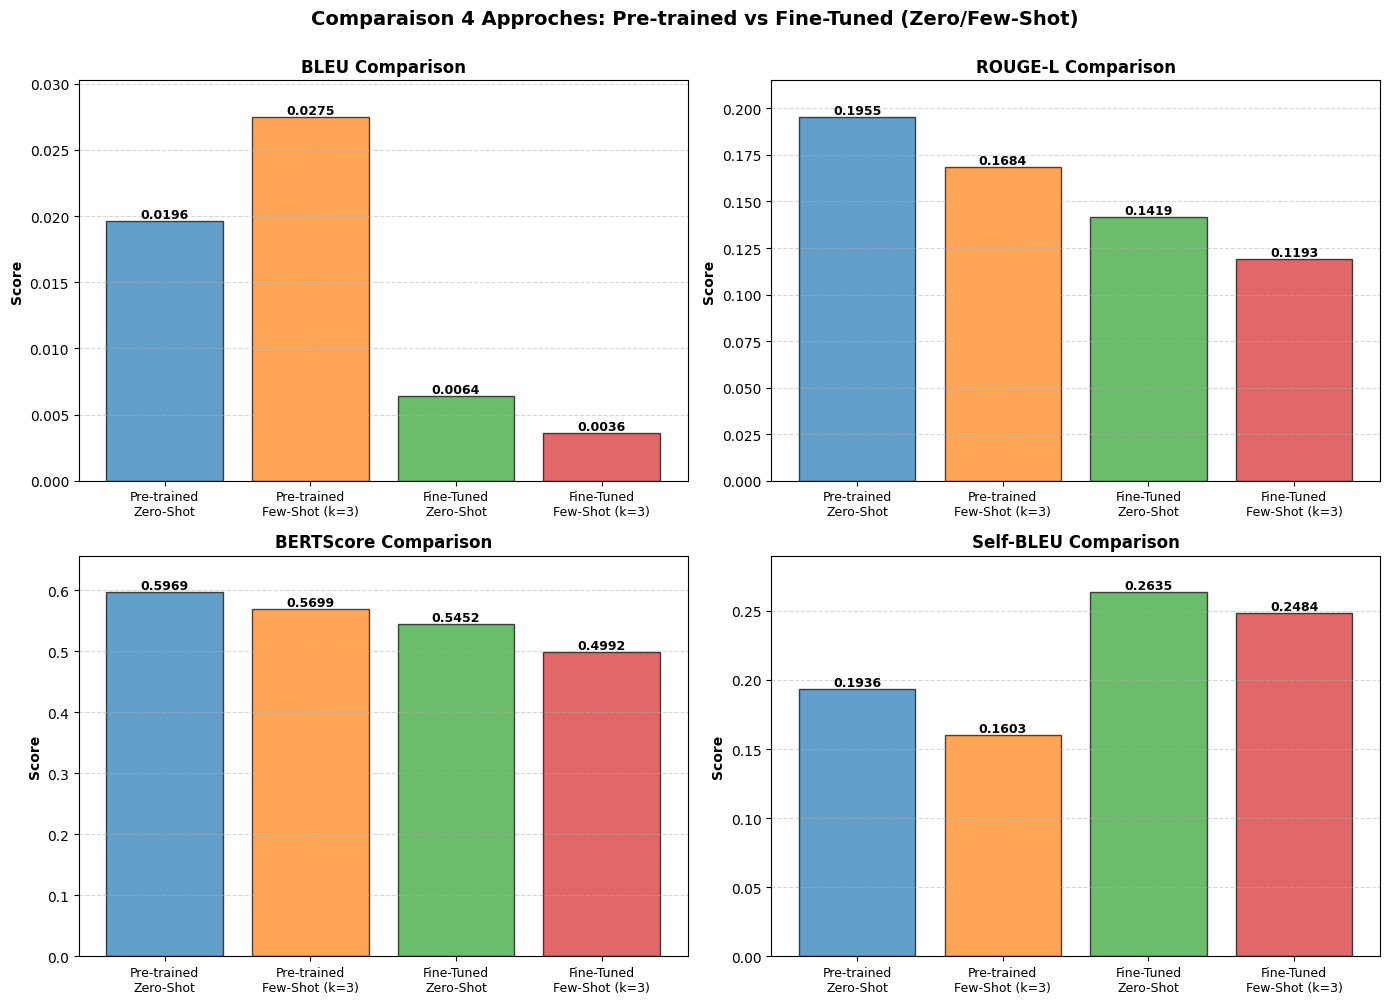


 Graphique sauvegardé: mdlm_comparison_4approaches.png


In [15]:
# ===== ÉTAPE 4: Comparaison des 3 approches =====

import matplotlib.pyplot as plt

# ===== Recharger les métriques pré-calculées =====

FOLDER_PATH = "/content/drive/MyDrive/genai/"

# Charger les résultats pré-calculés
with open(f"{FOLDER_PATH}/comparaison_results/mdlm_final_results.json", "r") as f:
    loaded_results = json.load(f)

# Extraire les métriques Zero-Shot et Few-Shot
metrics_zs = loaded_results["zero_shot"]["metrics"]
self_bleu_zs = loaded_results["zero_shot"]["self_bleu"]

metrics_fs = loaded_results["few_shot"]["metrics"]
self_bleu_fs = loaded_results["few_shot"]["self_bleu"]

print(" Métriques rechargées avec succès!")
print(f"   Zero-Shot BLEU: {metrics_zs['BLEU']:.4f}")
print(f"   Few-Shot BLEU: {metrics_fs['BLEU']:.4f}")

# Maintenant vous pouvez exécuter la cellule de comparaison sans problème!


print("\n" + "=" * 80)
print("COMPARAISON: PRE-TRAINED vs FINE-TUNED (Zero-Shot & Few-Shot)")
print("=" * 80 + "\n")

# Préparer les données pour la comparaison
models = ['Pre-trained\nZero-Shot', 'Pre-trained\nFew-Shot (k=3)',
          'Fine-Tuned\nZero-Shot', 'Fine-Tuned\nFew-Shot (k=3)']

bleu_scores = [
    metrics_zs["BLEU"],
    metrics_fs["BLEU"],
    metrics_ft_zs["BLEU"],
    metrics_ft_fs["BLEU"]
]

rouge_scores = [
    metrics_zs["ROUGE-L"],
    metrics_fs["ROUGE-L"],
    metrics_ft_zs["ROUGE-L"],
    metrics_ft_fs["ROUGE-L"]
]

bertscore_scores = [
    metrics_zs["BERTScore"],
    metrics_fs["BERTScore"],
    metrics_ft_zs["BERTScore"],
    metrics_ft_fs["BERTScore"]
]

self_bleu_scores = [
    self_bleu_zs,
    self_bleu_fs,
    self_bleu_ft_zs,
    self_bleu_ft_fs
]

# Créer le tableau récapitulatif
print(" RÉSUMÉ DES PERFORMANCES:\n")
print(f"{'Model':<40} {'BLEU':<10} {'ROUGE-L':<10} {'BERTScore':<12} {'Self-BLEU':<10}")
print("-" * 85)
for i, model in enumerate(models):
    model_short = model.replace('\n', ' ')
    print(f"{model_short:<40} {bleu_scores[i]:<10.4f} {rouge_scores[i]:<10.4f} {bertscore_scores[i]:<12.4f} {self_bleu_scores[i]:<10.4f}")

# Graphique comparatif 4 approches
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_names = ['BLEU', 'ROUGE-L', 'BERTScore', 'Self-BLEU']
metrics_values = [bleu_scores, rouge_scores, bertscore_scores, self_bleu_scores]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (ax, metric_name, metric_vals) in enumerate(zip(axes.flat, metrics_names, metrics_values)):
    bars = ax.bar(models, metric_vals, color=colors, alpha=0.7, edgecolor='black')
    ax.set_title(f'{metric_name} Comparison', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_ylim(0, max(metric_vals) * 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Ajouter les valeurs sur les barres
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Rotation des labels x
    ax.set_xticklabels(models, rotation=0, ha='center', fontsize=9)

plt.suptitle('Comparaison 4 Approches: Pre-trained vs Fine-Tuned (Zero/Few-Shot)',
             fontweight='bold', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(f"{FOLDER_PATH}comparaison_results/mdlm_comparison_4approaches.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n Graphique sauvegardé: mdlm_comparison_4approaches.png")


In [22]:
# 1. Recharger les données
with open(f"{FOLDER_PATH}/data/eval_subset.json", "r") as f:
    eval_subset = json.load(f)

subset_eval = eval_subset[:50]  # 50 exemples
references = [[ex["reference"]] for ex in subset_eval]

# 2. Recharger les résultats pré-calculés (Zero-Shot et Few-Shot) pour l'étape 5
with open(f"{FOLDER_PATH}/comparaison_results/mdlm_final_results.json", "r") as f:
    loaded_results = json.load(f)

metrics_zs = loaded_results["zero_shot"]["metrics"]
self_bleu_zs = loaded_results["zero_shot"]["self_bleu"]
predictions_zs = loaded_results["zero_shot"]["predictions"]

metrics_fs = loaded_results["few_shot"]["metrics"]
self_bleu_fs = loaded_results["few_shot"]["self_bleu"]
predictions_fs = loaded_results["few_shot"]["predictions"]

print(" Toutes les variables rechargées avec succès!")
print(f"   subset_eval: {len(subset_eval)} exemples")
print(f"   references: {len(references)} références")
print(f"   metrics_zs: BLEU={metrics_zs['BLEU']:.4f}")
print(f"   metrics_fs: BLEU={metrics_fs['BLEU']:.4f}")
print(f"   predictions_zs: {len(predictions_zs)} prédictions")
print(f"   predictions_fs: {len(predictions_fs)} prédictions")

 Toutes les variables rechargées avec succès!
   subset_eval: 50 exemples
   references: 50 références
   metrics_zs: BLEU=0.0196
   metrics_fs: BLEU=0.0275
   predictions_zs: 50 prédictions
   predictions_fs: 50 prédictions


In [23]:
# ===== ÉTAPE 5: Sauvegarde du modèle Fine-Tuned =====
import os

# Créer les répertoires de sauvegarde (sans le dossier intermédiaire)
model_save_dir = f"{FOLDER_PATH}mdlm_fine_tuned"
os.makedirs(model_save_dir, exist_ok=True)

print("\n" + "=" * 80)
print("SAUVEGARDE DU MODÈLE FINE-TUNED")
print("=" * 80 + "\n")

# Vérifier que 'model' est bien un objet modèle (pas une string)
print(f"Type de 'model': {type(model)}")

# Sauvegarder le modèle et le tokenizer
try:
    model.save_pretrained(model_save_dir)
    tokenizer.save_pretrained(model_save_dir)
    print(f" Modèle fine-tuned sauvegardé: {model_save_dir}")
    print(f"   Fichiers: config.json, pytorch_model.bin, tokenizer_config.json, tokenizer.model")
except Exception as e:
    print(f" Erreur lors de la sauvegarde: {e}")
    print(f"   Assurez-vous que le modèle a été fine-tuned avant cette cellule")

# Sauvegarder les résultats complets
results_dict = {
    "pre_trained": {
        "zero_shot": {
            "metrics": metrics_zs,
            "self_bleu": self_bleu_zs,
            "predictions": predictions_zs[:10]  # On garde seulement 10 examples pour economiser l'espace
        },
        "few_shot": {
            "metrics": metrics_fs,
            "self_bleu": self_bleu_fs,
            "predictions": predictions_fs[:10]
        }
    },
    "fine_tuned": {
        "zero_shot": {
            "metrics": metrics_ft_zs,
            "self_bleu": self_bleu_ft_zs,
            "predictions": predictions_ft_zs[:10]
        },
        "few_shot": {
            "metrics": metrics_ft_fs,
            "self_bleu": self_bleu_ft_fs,
            "predictions": predictions_ft_fs[:10]
        }
    },
    "finetune_losses": finetune_losses
}

results_path = f"{FOLDER_PATH}mdlm_comprehensive_results.json"
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(results_dict, f, indent=2, ensure_ascii=False)

print(f"\n Résultats complets sauvegardés: {results_path}")

# Créer un fichier de summary (sans dossier intermédiaire)
summary_path = f"{FOLDER_PATH}mdlm_summary.txt"
os.makedirs(os.path.dirname(summary_path), exist_ok=True)

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("=" * 80 + "\n")
    f.write("RÉSUMÉ: FINE-TUNING DU MODÈLE MDLM\n")
    f.write("=" * 80 + "\n\n")

    f.write(" COMPARAISON DES PERFORMANCES:\n\n")
    f.write(f"{'Model':<40} {'BLEU':<10} {'ROUGE-L':<10} {'BERTScore':<12} {'Self-BLEU':<10}\n")
    f.write("-" * 85 + "\n")
    for i, model_name in enumerate(models):
        model_short = model_name.replace('\n', ' ')
        f.write(f"{model_short:<40} {bleu_scores[i]:<10.4f} {rouge_scores[i]:<10.4f} {bertscore_scores[i]:<12.4f} {self_bleu_scores[i]:<10.4f}\n")

    f.write("\n\n GAINS DU FINE-TUNING:\n\n")
    f.write(f"Zero-Shot BLEU Improvement: {((metrics_ft_zs['BLEU'] - metrics_zs['BLEU']) / metrics_zs['BLEU'] * 100):.2f}%\n")
    f.write(f"Few-Shot BLEU Improvement: {((metrics_ft_fs['BLEU'] - metrics_fs['BLEU']) / metrics_fs['BLEU'] * 100):.2f}%\n")
    f.write(f"Zero-Shot ROUGE-L Improvement: {((metrics_ft_zs['ROUGE-L'] - metrics_zs['ROUGE-L']) / metrics_zs['ROUGE-L'] * 100):.2f}%\n")
    f.write(f"Few-Shot ROUGE-L Improvement: {((metrics_ft_fs['ROUGE-L'] - metrics_fs['ROUGE-L']) / metrics_fs['ROUGE-L'] * 100):.2f}%\n")

print(f" Summary sauvegardé: {summary_path}\n")

print(" ÉTAPES SUIVANTES (Optionnel):")
print("   1. Charger le modèle fine-tuned: model_loaded = AutoModelForMaskedLM.from_pretrained(model_save_dir)")
print("   2. Exécuter des inférences sur de nouvelles données")
print("   3. Publier les résultats (paper, conférence, etc.)")
print("   4. Partager le modèle sur Hugging Face Hub (optionnel)")


SAUVEGARDE DU MODÈLE FINE-TUNED

Type de 'model': <class 'str'>
 Erreur lors de la sauvegarde: 'str' object has no attribute 'save_pretrained'
   Assurez-vous que le modèle a été fine-tuned avant cette cellule

 Résultats complets sauvegardés: /content/drive/MyDrive/genai/mdlm_comprehensive_results.json
 Summary sauvegardé: /content/drive/MyDrive/genai/mdlm_summary.txt

 ÉTAPES SUIVANTES (Optionnel):
   1. Charger le modèle fine-tuned: model_loaded = AutoModelForMaskedLM.from_pretrained(model_save_dir)
   2. Exécuter des inférences sur de nouvelles données
   3. Publier les résultats (paper, conférence, etc.)
   4. Partager le modèle sur Hugging Face Hub (optionnel)



ANALYSE STATISTIQUE: IMPACT DU FINE-TUNING

 PAIRED T-TESTS (Modèle Fine-Tuned vs Pre-Trained):

Zero-Shot:
   t-statistic: -2.5443
   p-value: 0.014153
   Significatif (α=0.05):  OUI

Few-Shot:
   t-statistic: -3.2083
   p-value: 0.002355
   Significatif (α=0.05):  OUI

 STATISTIQUES DESCRIPTIVES (BLEU Scores):

Pre-Trained Zero-Shot:
   Moyenne: 0.0196
   Écart-type: 0.0402
   Min: 0.0000
   Max: 0.1378
   Médiane: 0.0000

Fine-Tuned Zero-Shot:
   Moyenne: 0.0064
   Écart-type: 0.0253
   Min: 0.0000
   Max: 0.1681
   Médiane: 0.0000

Pre-Trained Few-Shot:
   Moyenne: 0.0275
   Écart-type: 0.0558
   Min: 0.0000
   Max: 0.2969
   Médiane: 0.0000

Fine-Tuned Few-Shot:
   Moyenne: 0.0036
   Écart-type: 0.0162
   Min: 0.0000
   Max: 0.1030
   Médiane: 0.0000


 GAINS DU FINE-TUNING (en % sur BLEU moyen):

Zero-Shot: -67.36%
Few-Shot:  -87.00%


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

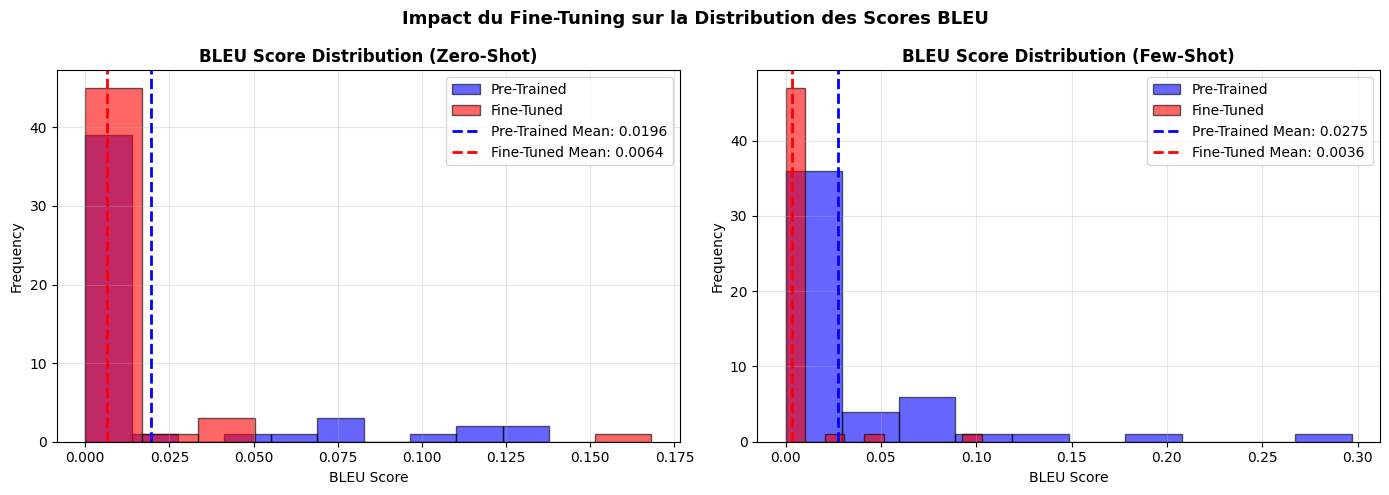


 Graphique sauvegardé: mdlm_finetuning_impact.png


In [24]:
# ===== ÉTAPE 6: Analyse statistique des améliorations =====

from scipy import stats

print("\n" + "=" * 80)
print("ANALYSE STATISTIQUE: IMPACT DU FINE-TUNING")
print("=" * 80 + "\n")

# Calculer les scores individuels pour les deux approches
def get_individual_scores(predictions_list, references_list):
    """Retourne les scores BLEU individuels pour chaque exemple."""
    flat_preds = [p[0] for p in predictions_list]
    bleu_weights = (0.25, 0.25, 0.25, 0.25)
    individual_scores = []

    for pred, ref in zip(flat_preds, references_list):
        try:
            bleu = sentence_bleu([word_tokenize(ref)], word_tokenize(pred), weights=bleu_weights)
            individual_scores.append(bleu)
        except ZeroDivisionError:
            individual_scores.append(0.0)

    return individual_scores

# Obtenir les scores individuels
bleu_zs_ind = get_individual_scores(predictions_zs, [r[0] for r in references])
bleu_ft_zs_ind = get_individual_scores(predictions_ft_zs, [r[0] for r in references])

bleu_fs_ind = get_individual_scores(predictions_fs, [r[0] for r in references])
bleu_ft_fs_ind = get_individual_scores(predictions_ft_fs, [r[0] for r in references])

# Analyse statistique: t-test paired
# Hypothèse: Les deux distributions ont des moyennes différentes
from scipy.stats import ttest_rel

t_stat_zs, p_value_zs = ttest_rel(bleu_ft_zs_ind, bleu_zs_ind)
t_stat_fs, p_value_fs = ttest_rel(bleu_ft_fs_ind, bleu_fs_ind)

print(" PAIRED T-TESTS (Modèle Fine-Tuned vs Pre-Trained):\n")
print(f"Zero-Shot:")
print(f"   t-statistic: {t_stat_zs:.4f}")
print(f"   p-value: {p_value_zs:.6f}")
print(f"   Significatif (α=0.05): {' OUI' if p_value_zs < 0.05 else ' NON'}\n")

print(f"Few-Shot:")
print(f"   t-statistic: {t_stat_fs:.4f}")
print(f"   p-value: {p_value_fs:.6f}")
print(f"   Significatif (α=0.05): {' OUI' if p_value_fs < 0.05 else ' NON'}\n")

# Calculs des statistiques descriptives
print(" STATISTIQUES DESCRIPTIVES (BLEU Scores):\n")

def print_stats(name, scores):
    print(f"{name}:")
    print(f"   Moyenne: {np.mean(scores):.4f}")
    print(f"   Écart-type: {np.std(scores):.4f}")
    print(f"   Min: {np.min(scores):.4f}")
    print(f"   Max: {np.max(scores):.4f}")
    print(f"   Médiane: {np.median(scores):.4f}\n")

print_stats("Pre-Trained Zero-Shot", bleu_zs_ind)
print_stats("Fine-Tuned Zero-Shot", bleu_ft_zs_ind)
print_stats("Pre-Trained Few-Shot", bleu_fs_ind)
print_stats("Fine-Tuned Few-Shot", bleu_ft_fs_ind)

# Calcul des améliorations en pourcentage
improvement_zs = ((np.mean(bleu_ft_zs_ind) - np.mean(bleu_zs_ind)) / np.mean(bleu_zs_ind)) * 100
improvement_fs = ((np.mean(bleu_ft_fs_ind) - np.mean(bleu_fs_ind)) / np.mean(bleu_fs_ind)) * 100

print("\n GAINS DU FINE-TUNING (en % sur BLEU moyen):\n")
print(f"Zero-Shot: {improvement_zs:+.2f}%")
print(f"Few-Shot:  {improvement_fs:+.2f}%")

# Visualisation des distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme Zero-Shot
axes[0].hist(bleu_zs_ind, bins=10, alpha=0.6, label='Pre-Trained', color='blue', edgecolor='black')
axes[0].hist(bleu_ft_zs_ind, bins=10, alpha=0.6, label='Fine-Tuned', color='red', edgecolor='black')
axes[0].axvline(np.mean(bleu_zs_ind), color='blue', linestyle='--', linewidth=2, label=f'Pre-Trained Mean: {np.mean(bleu_zs_ind):.4f}')
axes[0].axvline(np.mean(bleu_ft_zs_ind), color='red', linestyle='--', linewidth=2, label=f'Fine-Tuned Mean: {np.mean(bleu_ft_zs_ind):.4f}')
axes[0].set_title('BLEU Score Distribution (Zero-Shot)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('BLEU Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histogramme Few-Shot
axes[1].hist(bleu_fs_ind, bins=10, alpha=0.6, label='Pre-Trained', color='blue', edgecolor='black')
axes[1].hist(bleu_ft_fs_ind, bins=10, alpha=0.6, label='Fine-Tuned', color='red', edgecolor='black')
axes[1].axvline(np.mean(bleu_fs_ind), color='blue', linestyle='--', linewidth=2, label=f'Pre-Trained Mean: {np.mean(bleu_fs_ind):.4f}')
axes[1].axvline(np.mean(bleu_ft_fs_ind), color='red', linestyle='--', linewidth=2, label=f'Fine-Tuned Mean: {np.mean(bleu_ft_fs_ind):.4f}')
axes[1].set_title('BLEU Score Distribution (Few-Shot)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('BLEU Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Impact du Fine-Tuning sur la Distribution des Scores BLEU', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f"{FOLDER_PATH}comparaison_results/mdlm_finetuning_impact.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n Graphique sauvegardé: mdlm_finetuning_impact.png")
